In [ ]:
#step 0
import os
import math
import random
import warnings
import logging
from dataclasses import dataclass, field
from typing import Tuple, Optional, List, Dict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.preprocessing import StandardScaler

from tqdm import tqdm
from IPython.display import display

import types
import matplotlib
import matplotlib.pyplot as plt

CSV_PATH = "DecorderOnlyS&P.csv"

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


Mounted at /content/drive


In [ ]:
#step1
def load_ohlcv_csv(path: str, add_tech_indicators: bool = False) -> pd.DataFrame:
    logger.info(f"正在讀取 CSV: {path}")
    df = pd.read_csv(path, sep="|")

    df = df.loc[:, ~df.columns.astype(str).str.fullmatch(r"\s*")]
    alias_map = {
        "date": "Date", "timestamp": "Date", "time": "Date",
        "open": "Open", "high": "High", "low": "Low",
        "close": "Close", "adj close": "Close", "adj_close": "Close", "adjclose": "Close",
        "volume": "Volume", "vol": "Volume",
    }
    lower_to_orig = {c.lower(): c for c in df.columns}
    rename_dict = {lower_to_orig[k]: v for k, v in alias_map.items() if k in lower_to_orig}
    df = df.rename(columns=rename_dict)

    need = ["Date", "Open", "High", "Low", "Close"]
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise ValueError(f"CSV 缺少必要欄位: {missing}；現有欄位: {list(df.columns)}")

    if "Volume" not in df.columns:
        logger.warning("CSV 沒有 Volume 欄位，使用預設值 0")
        df["Volume"] = 0.0
    need.append("Volume")

    n0 = len(df)
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce", utc=False)
    for c in ["Open", "High", "Low", "Close", "Volume"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=need)
    df = df.drop_duplicates(subset=["Date"]).sort_values("Date").reset_index(drop=True)

    invalid = (
        (df["Open"] <= 0) | (df["High"] <= 0) | (df["Low"] <= 0) | (df["Close"] <= 0) |
        (df["Volume"] < 0) | (df["High"] < df["Low"]) |
        (df["Open"] > df["High"]) | (df["Open"] < df["Low"]) |
        (df["Close"] > df["High"]) | (df["Close"] < df["Low"])
    )
    if invalid.any():
        logger.warning(f"發現 {invalid.sum()} 筆不合理價格(含<=0)或成交量，已移除")
        df = df[~invalid].reset_index(drop=True)

    n1 = len(df)
    if n1 != n0:
        logger.info(f"清洗後剩餘 {n1} 筆（移除 {n0 - n1} 筆）")

    if add_tech_indicators:
        try:
            from ta import add_all_ta_features
            df = add_all_ta_features(
                df, open="Open", high="High", low="Low", close="Close", volume="Volume", fillna=True
            )
            logger.info("已添加技術指標")
        except ImportError:
            raise ImportError("需要安裝 'ta' 套件方可添加技術指標")

    return df


def add_relative_targets(df: pd.DataFrame, base_col: str = "Close", method: str = "ratio") -> pd.DataFrame:
    prev_close = df[base_col].shift(1)
    if method == "ratio":
        df["High_rel"]  = (df["High"]  / prev_close) - 1.0
        df["Low_rel"]   = (df["Low"]   / prev_close) - 1.0
        df["Close_rel"] = (df["Close"] / prev_close) - 1.0
    elif method == "diff":
        df["High_rel"]  = df["High"]  - prev_close
        df["Low_rel"]   = df["Low"]   - prev_close
        df["Close_rel"] = df["Close"] - prev_close
    else:
        raise ValueError("method 必須是 'ratio' 或 'diff'")
    return df


def apply_features(df):
    df = df.copy()
    eps = 1e-8

    df['y1'] = np.log(df['Low'] + eps)

    df['y2'] = np.log(df['High'] - df['Low'] + eps)

    h_l_range = (df['High'] - df['Low'] + eps)
    lambda_o = ((df['Open'] - df['Low']) / h_l_range).clip(eps, 1-eps)
    lambda_c = ((df['Close'] - df['Low']) / h_l_range).clip(eps, 1-eps)

    df['y3'] = np.log(lambda_o / (1 - lambda_o))
    df['y4'] = np.log(lambda_c / (1 - lambda_c))

    return df

@dataclass
class Scalers:
    x_scaler: StandardScaler
    y_scalers: Dict[str, StandardScaler] = field(default_factory=dict)
    x_cols: List[str] = field(default_factory=lambda: ["Open", "High", "Low", "Close", "Volume"])
    y_cols: List[str] = field(default_factory=lambda: ["High", "Low", "Close"])
    train_minmax: Dict[str, Tuple[float, float]] = field(default_factory=dict)
    dataset_minmax: Dict[str, Tuple[float, float]] = field(default_factory=dict)
    target_mode: str = "absolute"
    relative_def: str = "ratio"
    base_col: str = "Close"

    def update_x_cols(self, df: pd.DataFrame):
        deny = set(["Date", "High_rel", "Low_rel", "Close_rel", "Open", "High", "Low", "Close"])
        base = ["y1", "y2", "y3", "y4", "Volume"]
        xcols = [c for c in base if c in df.columns]
        extras = [c for c in df.columns if c not in deny and c not in xcols]
        self.x_cols = xcols + extras
        logger.info(f"更新 x_cols 共 {len(self.x_cols)} 欄: {self.x_cols[:8]}...")

    def inverse_transform_y(self, Y: np.ndarray, col: str) -> np.ndarray:
        if col not in self.y_scalers:
            raise ValueError(f"未知的 y_col: {col}")
        scaler = self.y_scalers[col]
        orig_shape = Y.shape
        if Y.ndim == 3:
            Y2 = Y.reshape(-1, 1)
        elif Y.ndim == 2:
            Y2 = Y
        elif Y.ndim == 1:
            Y2 = Y.reshape(-1, 1)
        else:
            raise ValueError(f"不支援的 Y 維度：{Y.ndim}")
        Y_inv = scaler.inverse_transform(Y2)
        return Y_inv.reshape(orig_shape)

    def relative_to_raw(self, Y_rel: np.ndarray, base: np.ndarray) -> np.ndarray:
        if self.relative_def == "ratio":
            return base * (1.0 + Y_rel)
        elif self.relative_def == "diff":
            return base + Y_rel
        else:
            raise ValueError("relative_def 必須是 'ratio' 或 'diff'")


def fit_scalers(train_df: pd.DataFrame, scalers: Optional[Scalers] = None) -> Scalers:
    if scalers is None:
        scalers = Scalers(StandardScaler())

    df_log = train_df.copy()
    df_log["Volume"] = np.log1p(df_log["Volume"])
    scalers.update_x_cols(train_df)

    x_data = df_log[scalers.x_cols].values
    scalers.x_scaler.fit(x_data)

    if scalers.target_mode == "absolute":
        src_high  = train_df["High"].values.reshape(-1, 1)
        src_low   = train_df["Low"].values.reshape(-1, 1)
        src_close = train_df["Close"].values.reshape(-1, 1)
    else:
        need_cols = ["High_rel", "Low_rel", "Close_rel"]
        if any(c not in train_df.columns for c in need_cols):
            raise ValueError("relative 目標需要先在『整體 df』呼叫 add_relative_targets() 並保留 High_rel/Low_rel/Close_rel")
        src_high  = train_df["High_rel"].values.reshape(-1, 1)
        src_low   = train_df["Low_rel"].values.reshape(-1, 1)
        src_close = train_df["Close_rel"].values.reshape(-1, 1)

    scalers.y_scalers["High"]  = StandardScaler().fit(src_high)
    scalers.y_scalers["Low"]   = StandardScaler().fit(src_low)
    scalers.y_scalers["Close"] = StandardScaler().fit(src_close)

    for k in ["High", "Low", "Close"]:
        sc = scalers.y_scalers[k]
        logger.info(f"Fitted y_scaler[{k}] mean={sc.mean_[0]:.6f}, std={sc.scale_[0]:.6f}")

    return scalers


def apply_scalers(df: pd.DataFrame, scalers: Scalers) -> Tuple[np.ndarray, np.ndarray]:
    df_log = df.copy()
    df_log["Volume"] = np.log1p(df_log["Volume"])
    X = scalers.x_scaler.transform(df_log[scalers.x_cols].values).astype(np.float32)

    if scalers.target_mode == "absolute":
        y_src = df[["High", "Low", "Close"]].values
    else:
        need = ["High_rel", "Low_rel", "Close_rel"]
        if any(c not in df.columns for c in need):
            raise ValueError("relative 目標需要 add_relative_targets()，且包含 High_rel/Low_rel/Close_rel")
        y_src = df[["High_rel", "Low_rel", "Close_rel"]].values

    y_high_z  = scalers.y_scalers["High"].transform(y_src[:, [0]])
    y_low_z   = scalers.y_scalers["Low"].transform(y_src[:, [1]])
    y_close_z = scalers.y_scalers["Close"].transform(y_src[:, [2]])
    Y = np.concatenate([y_high_z, y_low_z, y_close_z], axis=1).astype(np.float32)

    logger.info(f"apply_scalers: X={X.shape}, Y={Y.shape}（Y 最後維度=3: High/Low/Close）")
    return X, Y


class OHLCVDataset(Dataset):
    def __init__(self, X: np.ndarray, Y: np.ndarray, L: int, H: int, dates: Optional[pd.Series] = None):
        super().__init__()
        assert X.ndim == 2 and Y.ndim == 2 and X.shape[0] == Y.shape[0]
        self.X, self.Y, self.L, self.H = X, Y, int(L), int(H)
        self.dates = dates.reset_index(drop=True) if dates is not None else None
        N = len(X)
        self.indices = list(range(self.L - 1, N - self.H))
        if not self.indices:
            raise ValueError(f"無有效序列 (L={L}, H={H}, N={N})")
        logger.info(f"OHLCVDataset: L={L}, H={H}, 樣本數={len(self.indices)}")

    def __len__(self): return len(self.indices)

    def __getitem__(self, idx: int):
        t = self.indices[idx]
        x_hist = self.X[t - self.L + 1 : t + 1]
        y_seq  = self.Y[t + 1 : t + 1 + self.H]
        return torch.from_numpy(x_hist), torch.from_numpy(y_seq)


def train_val_test_split(df: pd.DataFrame, train_ratio=0.7, val_ratio=0.15,
                         date_splits: Optional[pd.Timestamp] = None,
                         min_samples_per_set: Optional[int] = None):
    assert 0 < train_ratio < 1 and 0 < val_ratio < 1 and train_ratio + val_ratio < 1
    if date_splits:
        train_end, val_end = pd.to_datetime(date_splits[0]), pd.to_datetime(date_splits[1])
        train_df = df[df["Date"] <= train_end].copy()
        val_df   = df[(df["Date"] > train_end) & (df["Date"] <= val_end)].copy()
        test_df  = df[df["Date"] > val_end].copy()
    else:
        N = len(df); n_train = int(N * train_ratio); n_val = int(N * val_ratio)
        train_df = df.iloc[:n_train].copy()
        val_df   = df.iloc[n_train:n_train + n_val].copy()
        test_df  = df.iloc[n_train + n_val:].copy()

    for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
        assert len(d) > 0, f"{name} split 為空"
        assert d["Date"].is_monotonic_increasing, f"{name} 日期未單調遞增，請檢查排序"

    assert train_df["Date"].max() < val_df["Date"].min(), "train/val 邊界重疊或順序錯誤"
    assert val_df["Date"].max()   < test_df["Date"].min(), "val/test 邊界重疊或順序錯誤"

    if min_samples_per_set:
        for name, d in [("訓練集", train_df), ("驗證集", val_df), ("測試集", test_df)]:
            if len(d) < min_samples_per_set:
                raise ValueError(f"{name} 資料量 {len(d)} 不足")

    logger.info(f"資料切分: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
    return train_df, val_df, test_df


def make_dataloaders(csv_path: str, L: int, H: int, batch_size=64, num_workers=None,
                     add_tech_indicators=False, date_splits=None,
                     target_mode: str = "relative",
                     relative_def: str = "ratio"):

    df = load_ohlcv_csv(csv_path, add_tech_indicators=add_tech_indicators)

    if target_mode == "relative":
        df = add_relative_targets(df, base_col="Close", method=relative_def)
        df = df.dropna(subset=["High_rel", "Low_rel", "Close_rel"]).reset_index(drop=True)

    min_samples = L + H
    train_df, val_df, test_df = train_val_test_split(df, 0.7, 0.15, date_splits, min_samples)

    train_df = apply_features(train_df)
    val_df   = apply_features(val_df)
    test_df  = apply_features(test_df)

    scalers = Scalers(StandardScaler(), target_mode=target_mode, relative_def=relative_def, base_col="Close")
    scalers.y_cols = ["High", "Low", "Close"]

    scalers = fit_scalers(train_df, scalers)

    X_train, Y_train = apply_scalers(train_df, scalers)
    X_val,   Y_val   = apply_scalers(val_df,   scalers)
    X_test,  Y_test  = apply_scalers(test_df,  scalers)

    scalers.train_minmax = {
        "High": (float(train_df["High"].min()), float(train_df["High"].max())),
        "Low":  (float(train_df["Low"].min()),  float(train_df["Low"].max()))
    }
    scalers.dataset_minmax = {
        "High": (float(df["High"].min()), float(df["High"].max())),
        "Low":  (float(df["Low"].min()),  float(df["Low"].max()))
    }

    ds_train = OHLCVDataset(X_train, Y_train, L, H, dates=train_df["Date"])
    ds_val   = OHLCVDataset(X_val,   Y_val,   L, H, dates=val_df["Date"])
    ds_test  = OHLCVDataset(X_test,  Y_test,  L, H, dates=test_df["Date"])

    if num_workers is None:
        num_workers = min(os.cpu_count() or 1, 4)
    bs = min(batch_size, len(ds_train)) if len(ds_train) > 0 else 1
    pin = torch.cuda.is_available()

    dl_train = DataLoader(ds_train, batch_size=bs, shuffle=True,
                          num_workers=num_workers, drop_last=False, pin_memory=pin)
    dl_val   = DataLoader(ds_val, batch_size=bs, shuffle=False,
                          num_workers=num_workers, drop_last=False, pin_memory=pin)
    dl_test  = DataLoader(ds_test, batch_size=bs, shuffle=False,
                          num_workers=num_workers, drop_last=False, pin_memory=pin)

    return dl_train, dl_val, dl_test, scalers

In [ ]:
#step2
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 2048):
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len
        self._build_pe(max_len, d_model)

    def _build_pe(self, max_len: int, d_model: int):
        pe = torch.zeros(max_len, d_model, dtype=torch.float32)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe, persistent=False)

    def add_pe(self, x: torch.Tensor) -> torch.Tensor:
        T = x.size(1)
        if T > self.pe.size(0):
            raise RuntimeError(f"PositionalEncoding 長度不足：T={T} > max_len={self.pe.size(0)}，"
                               f"請呼叫 model.extend_max_len({T}) 擴充。")
        return x + self.pe[:T].unsqueeze(0).to(x.device)


class DecoderBlock(nn.Module):
    def __init__(self, d_model: int, nhead: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout)
        )

    def forward(self, x: torch.Tensor, attn_mask: torch.Tensor) -> torch.Tensor:
        h = self.ln1(x)
        h, _ = self.attn(h, h, h, attn_mask=attn_mask, need_weights=False)
        x = x + h
        h = self.ln2(x)
        h = self.ff(h)
        return x + h


def causal_mask(T: int, device: torch.device) -> torch.Tensor:
    return torch.triu(torch.ones(T, T, dtype=torch.bool, device=device), diagonal=1)


class DecoderOnlyTSModel(nn.Module):
    def __init__(
        self,
        d_in: int = 5,
        d_out: int = 3,
        d_model: int = 128,
        nhead: int = 8,
        num_layers: int = 2,
        d_ff: int = 256,
        dropout: float = 0.1,
        max_len: int = 2048
    ):
        super().__init__()
        assert d_model % nhead == 0, "d_model 必須能被 nhead 整除"
        self.d_out = d_out
        self.max_len = max_len

        self.in_proj  = nn.Linear(d_in,  d_model)
        self.tgt_proj = nn.Linear(d_out, d_model)

        self.sot = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.sot, std=0.02)

        self.hist_attn   = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.hist_ln_in  = nn.LayerNorm(d_model)
        self.hist_ln_out = nn.LayerNorm(d_model)

        self.pos = PositionalEncoding(d_model, max_len=max_len)
        self.blocks = nn.ModuleList([DecoderBlock(d_model, nhead, d_ff, dropout) for _ in range(num_layers)])
        self.out = nn.Linear(d_model, d_out)

        self.reset_parameters()
        logger.info(f"模型初始化：d_in={d_in}, d_out={d_out}, d_model={d_model}, "
                    f"nhead={nhead}, layers={num_layers}, max_len={max_len}")

    def extend_max_len(self, new_max_len: int):
        if new_max_len <= self.pos.pe.size(0):
            return
        self.max_len = new_max_len
        d_model = self.pos.pe.size(1)
        self.pos._build_pe(new_max_len, d_model)
        logger.info(f"已擴充 PositionalEncoding 長度至 {new_max_len}")

    def reset_parameters(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, hist_feat: torch.Tensor, tgt_in: torch.Tensor) -> torch.Tensor:
        assert hist_feat.dim() == 3 and tgt_in.dim() == 3, "hist_feat/tgt_in 維度應為 3"
        B, L, Dx = hist_feat.shape
        B2, H, Dout = tgt_in.shape
        assert B == B2, "batch 不一致"
        assert Dout == self.d_out, f"tgt_in 最後維度需為 {self.d_out}"
        assert H >= 1, "tgt_in 的時間步 H 必須 >= 1"

        needed_len = H + 1
        if needed_len > self.pos.pe.size(0):
            raise RuntimeError(
                f"需要的位置編碼長度 {needed_len} 大於 max_len={self.pos.pe.size(0)}。"
                f"請先呼叫 model.extend_max_len({needed_len}) 擴充。"
            )

        hist = self.in_proj(hist_feat)
        h_in = self.hist_ln_in(hist)
        hist_ctx, _ = self.hist_attn(h_in, h_in, h_in, need_weights=False)
        hist_ctx = self.hist_ln_out(hist_ctx + hist)

        tgt_cond  = tgt_in[:, :-1, :] if H > 1 else torch.zeros(B, 0, self.d_out, device=tgt_in.device, dtype=tgt_in.dtype)
        tgt_tokens = self.tgt_proj(tgt_cond)
        sot       = self.sot.expand(B, 1, -1)
        dec_in    = torch.cat([sot, tgt_tokens], dim=1)
        start_token = hist_ctx[:, -1:, :]
        x = torch.cat([start_token, dec_in], dim=1)
        x = self.pos.add_pe(x)

        mask = causal_mask(x.size(1), x.device)
        for blk in self.blocks:
            x = blk(x, attn_mask=mask)

        return self.out(x[:, 1:, :])

    @torch.no_grad()
    def predict(self, hist_feat: torch.Tensor, H: int) -> torch.Tensor:
        self.eval()
        device = hist_feat.device

        needed_len = 2 + (H - 1)
        if needed_len > self.pos.pe.size(0):
            logger.warning(
                f"推論序列可能超出 PE 長度：需要 {needed_len}，目前 max_len={self.pos.pe.size(0)}。"
                f"請在推論前呼叫 model.extend_max_len({needed_len})。"
            )

        hist = self.in_proj(hist_feat)
        h_in = self.hist_ln_in(hist)
        hist_ctx, _ = self.hist_attn(h_in, h_in, h_in, need_weights=False)
        hist_ctx = self.hist_ln_out(hist_ctx + hist)

        B = hist_feat.size(0)
        x = torch.cat([hist_ctx[:, -1:, :], self.sot.expand(B, 1, -1)], dim=1)
        x = x + self.pos.pe[:2].unsqueeze(0).to(device)

        outs = []
        for step_i in range(H):
            mask = causal_mask(x.size(1), device)
            h = x
            for blk in self.blocks:
                h = blk(h, attn_mask=mask)
            y = self.out(h[:, -1, :])
            outs.append(y)

            if step_i < H - 1:
                y_emb = self.tgt_proj(y).unsqueeze(1)
                next_pos = x.size(1)
                if next_pos >= self.pos.pe.size(0):
                    raise RuntimeError(
                        f"推論過程需要的位置 {next_pos} 超過 max_len={self.pos.pe.size(0)}，"
                        f"請在推論前呼叫 model.extend_max_len({next_pos+1})。"
                    )
                y_emb = y_emb + self.pos.pe[next_pos:next_pos+1].unsqueeze(0).to(device)
                x = torch.cat([x, y_emb], dim=1)

        return torch.stack(outs, dim=1)

In [ ]:
#step3
CKPT_DIR = "model_checkpoints"

with open(f"{CKPT_DIR}/scalers_hl.pkl", "rb") as f:
    GLOBAL_SCALERS = pickle.load(f)

GLOBAL_MODELS = {}
for (L, H), scalers in GLOBAL_SCALERS.items():
    Dx = len(scalers.x_cols)
    model = DecoderOnlyTSModel(
        d_in=Dx, d_out=3,
        d_model=128, nhead=8, num_layers=2, d_ff=256, dropout=0.1
    )
    ckpt_path = f"{CKPT_DIR}/model_hl_L{L}_H{H}.pt"
    model.load_state_dict(torch.load(ckpt_path, map_location="cpu"))
    model.eval()
    GLOBAL_MODELS[(L, H)] = model
    print(f"[LOAD] HL model L={L}, H={H} ✓")

with open(f"{CKPT_DIR}/scalers_close.pkl", "rb") as f:
    GLOBAL_SCALERS_CLOSE = pickle.load(f)

GLOBAL_MODELS_CLOSE = {}
for (L, H), scalers_c in GLOBAL_SCALERS_CLOSE.items():
    Dx = len(scalers_c.x_cols)
    model_c = DecoderOnlyTSModel(
        d_in=Dx, d_out=1,
        d_model=128, nhead=8, num_layers=2, d_ff=256, dropout=0.1
    )
    ckpt_path = f"{CKPT_DIR}/model_close_L{L}_H{H}.pt"
    model_c.load_state_dict(torch.load(ckpt_path, map_location="cpu"))
    model_c.eval()
    GLOBAL_MODELS_CLOSE[(L, H)] = model_c
    print(f"[LOAD] Close model L={L}, H={H} ✓")

GLOBAL_DL_VAL  = {}
GLOBAL_DL_TEST = {}

DATE_SPLITS = None

for (L, H) in GLOBAL_SCALERS.keys():
    _, dl_val, dl_test, _ = make_dataloaders(
        CSV_PATH, L=L, H=H, batch_size=64,
        date_splits=DATE_SPLITS,
        target_mode="relative", relative_def="ratio"
    )
    GLOBAL_DL_VAL[(L, H)]  = dl_val
    GLOBAL_DL_TEST[(L, H)] = dl_test
    print(f"[REBUILD] DataLoader L={L}, H={H} ✓")

[LOAD] HL model L=10, H=30 ✓
[LOAD] HL model L=10, H=60 ✓
[LOAD] HL model L=15, H=30 ✓
[LOAD] HL model L=15, H=60 ✓
[LOAD] Close model L=10, H=30 ✓
[LOAD] Close model L=10, H=60 ✓
[LOAD] Close model L=15, H=30 ✓
[LOAD] Close model L=15, H=60 ✓


# 特定市場

[INFO] Using model: L=10, H=30; HOLDS=[30]
[ALIGN] pred_df ready: N=932, range 2021-11-15 00:00:00 ~ 2025-08-04 00:00:00
[OK] Inference blocks aligned: P_raw (932, 30, 2) P_close (932, 30)
[STRESS TEST] 2022-01-03 ~ 2022-10-12: N=196

[sell_at_peak] === PredHL Pure 診斷 ===
  有效交易筆數 : 35
  跳過信號筆數 : 14（預測邊界不合理或子視窗退化）
  Exit reason  :
reason
PURE_SL      23
PURE_TP      11
PURE_NONE     1
  預測 TP 距離 : mean=2.07%  median=2.28%
  預測 SL 距離 : mean=-1.23%  median=-1.02%
  平均持有天數 : 3.2

[trough_then_peak] === PredHL Pure 診斷 ===
  有效交易筆數 : 25
  跳過信號筆數 : 39（預測邊界不合理或子視窗退化）
  Exit reason  :
reason
PURE_SL         14
PURE_TP         10
PURE_SL_SAME     1
  預測 TP 距離 : mean=1.61%  median=1.55%
  預測 SL 距離 : mean=-1.23%  median=-1.30%
  平均持有天數 : 3.2

[WARN] 以下策略 AvgHoldDays 異常短，結果可能不可信：
               Strategy  H  AvgHoldDays  Sharpe  Trades
       PredHL Pure Peak 30          3.2   -0.62      35
PredHL Pure Trough2Peak 30          3.2   -0.41      25

[ASSUMPTIONS]
 - HOLDS=[30]  |  model H=30  |  所有 K 

,Strategy,H,TotalReturn(%),B&H(%),CAGR(%),Sharpe,Sortino,Calmar,MaxDrawdown(%),ProfitFactor,WinRate(%),Trades,AvgHoldDays
0,Close Peak,30,-24.74%,-25.43%,-30.80%,-1.45,-1.88,-1.23,-25.04%,0.31,28.6%,7,26.0
1,Close Trough2Peak,30,-20.06%,-25.43%,-25.17%,-1.13,-1.48,-1.13,-22.25%,0.41,28.6%,7,25.0
2,HL Peak,30,-21.30%,-25.43%,-26.68%,-1.22,-1.62,-1.18,-22.52%,0.42,28.6%,7,26.0
3,HL Trough2Peak,30,-20.20%,-25.43%,-25.35%,-1.16,-1.54,-1.20,-21.11%,0.44,28.6%,7,25.0
4,PredHL Pure Peak,30,-8.95%,-25.43%,-11.43%,-0.62,-0.83,-1.04,-11.02%,0.65,31.4%,35,3.2
5,PredHL Pure Trough2Peak,30,-6.33%,-25.43%,-8.13%,-0.41,-0.56,-0.69,-11.83%,0.68,40.0%,25,3.2



=== Strategy Summary ===


,Strategy,TotalTrades,AvgHoldDays,WeightedWinRate(%),BestH(Sharpe),BestSharpe,BestH(Sortino),BestSortino,BestH(CAGR),BestCAGR(%),MaxProfitFactor
0,Close Peak,7.000000,26.0,28.57%,30.000000,-1.45,30.000000,-1.88,30.000000,-30.80%,0.31
1,Close Trough2Peak,7.000000,25.0,28.57%,30.000000,-1.13,30.000000,-1.48,30.000000,-25.17%,0.41
2,HL Peak,7.000000,26.0,28.57%,30.000000,-1.22,30.000000,-1.62,30.000000,-26.68%,0.42
3,HL Trough2Peak,7.000000,25.0,28.57%,30.000000,-1.16,30.000000,-1.54,30.000000,-25.35%,0.44
4,PredHL Pure Peak,35.000000,3.2,31.43%,30.000000,-0.62,30.000000,-0.83,30.000000,-11.43%,0.65
5,PredHL Pure Trough2Peak,25.000000,3.2,40.00%,30.000000,-0.41,30.000000,-0.56,30.000000,-8.13%,0.68



=== 步驟 A→B：信號貢獻（Close signal → HL signal，均無 TP/SL） ===
  比較方向：Close（G1）（A）→ HL（G2）（B）
  Δ = B − A；Δ > 0 代表 HL（G2） 佔優


,比較,H,A值 TotalRet,B值 TotalRet,ΔTotalReturn(%),ΔCAGR(%),ΔSharpe,ΔSortino,ΔMaxDrawdown(%),ΔWinRate(%),ΔTrades
0,Peak,30,-24.74%,-21.30%,+3.44%,+4.12%,+0.23,+0.26,+2.52%,+0.00%,+0
1,Trough2Peak,30,-20.06%,-20.20%,-0.14%,-0.18%,-0.03,-0.06,+1.14%,+0.00%,+0



=== 步驟 B→C：風控貢獻（HL signal 固定，加入 PredHL TP/SL） ===
  比較方向：HL 無風控（G2）（A）→ PredHL Pure（G3）（B）
  Δ = B − A；Δ > 0 代表 PredHL Pure（G3） 佔優


,比較,H,A值 TotalRet,B值 TotalRet,ΔTotalReturn(%),ΔCAGR(%),ΔSharpe,ΔSortino,ΔMaxDrawdown(%),ΔWinRate(%),ΔTrades
0,Peak,30,-21.30%,-8.95%,+12.35%,+15.25%,+0.60,+0.79,+11.50%,+2.86%,+28
1,Trough2Peak,30,-20.20%,-6.33%,+13.87%,+17.22%,+0.75,+0.98,+9.28%,+11.43%,+18



=== 步驟 A→C：HL 預測總效果（Close 基準 → PredHL Pure，無外部指標） ===
  比較方向：Close 基準（G1）（A）→ PredHL Pure（G3）（B）
  Δ = B − A；Δ > 0 代表 PredHL Pure（G3） 佔優


,比較,H,A值 TotalRet,B值 TotalRet,ΔTotalReturn(%),ΔCAGR(%),ΔSharpe,ΔSortino,ΔMaxDrawdown(%),ΔWinRate(%),ΔTrades
0,Peak,30,-24.74%,-8.95%,+15.79%,+19.37%,+0.83,+1.05,+14.02%,+2.86%,+28
1,Trough2Peak,30,-20.06%,-6.33%,+13.73%,+17.04%,+0.72,+0.92,+10.42%,+11.43%,+18


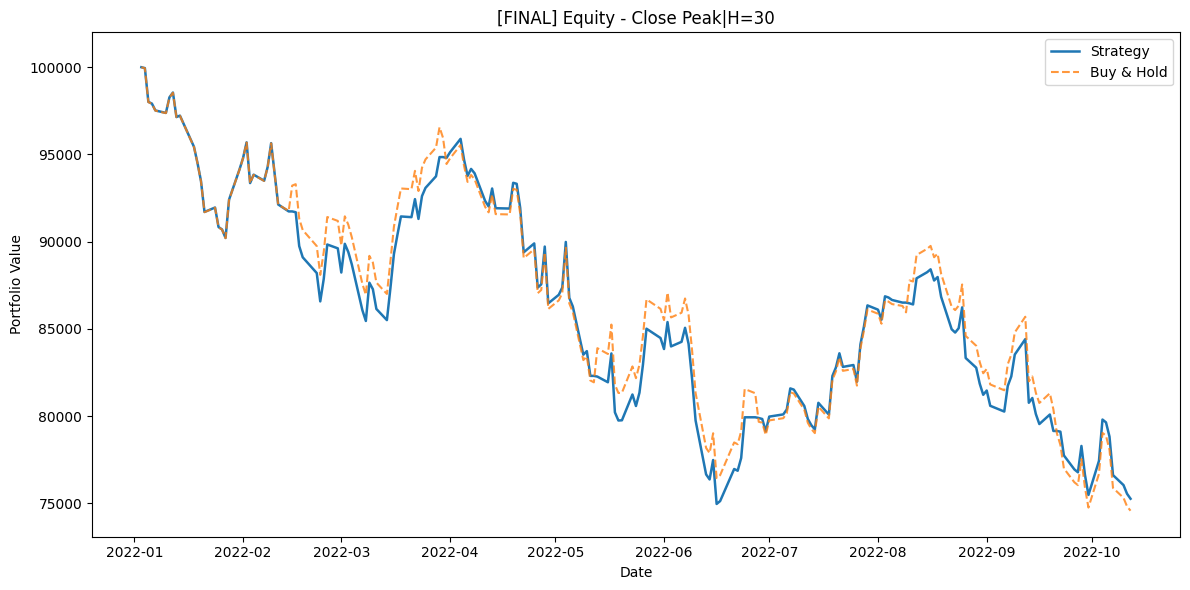

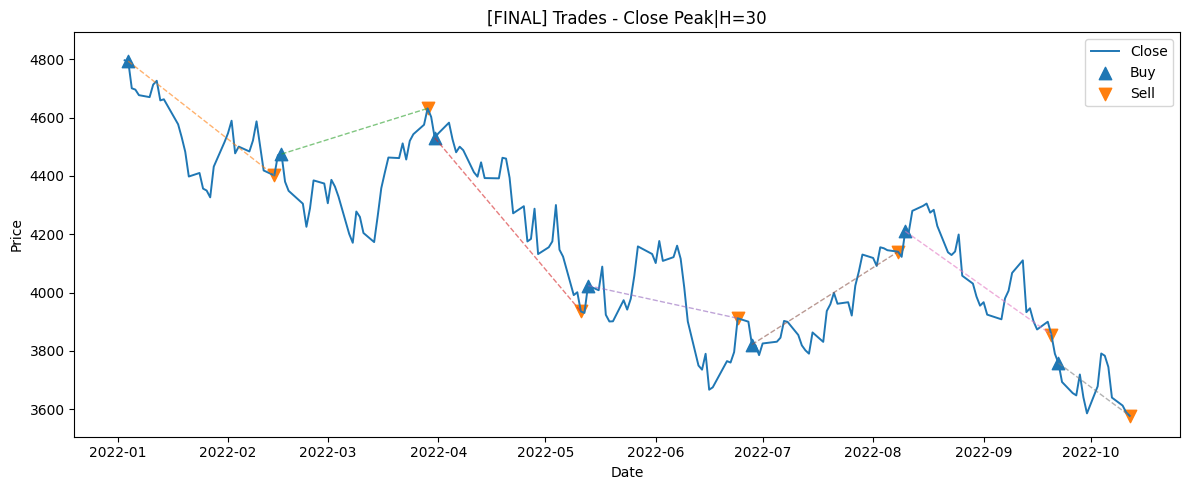

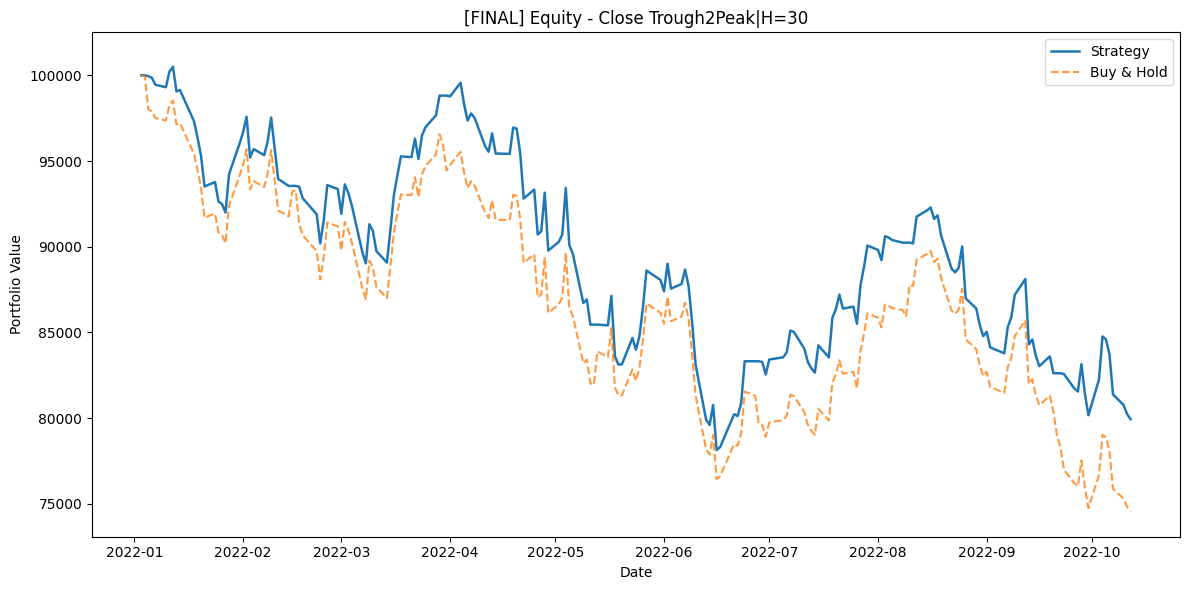

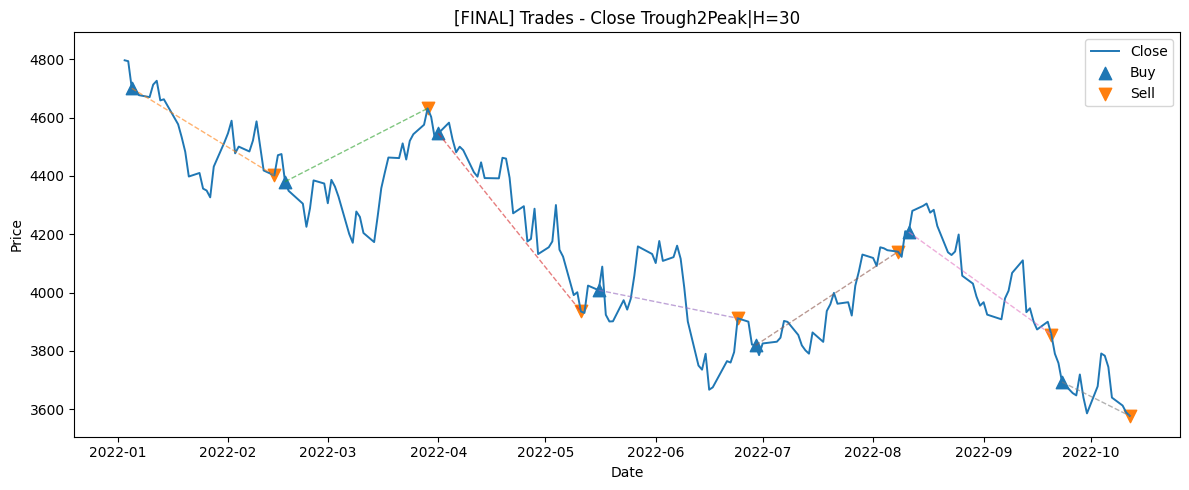

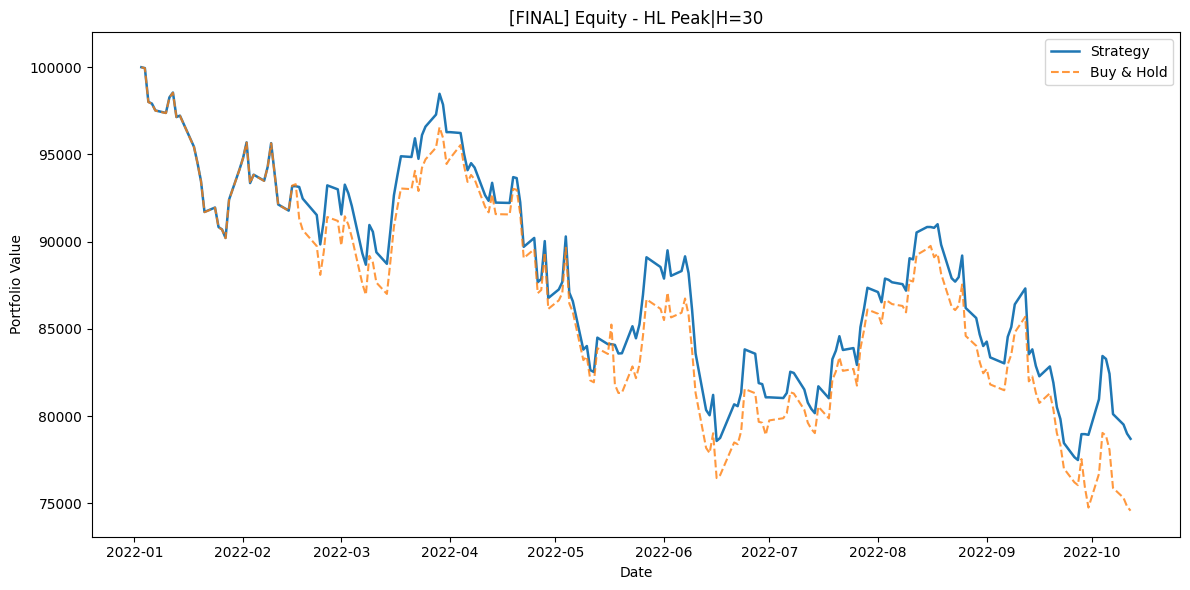

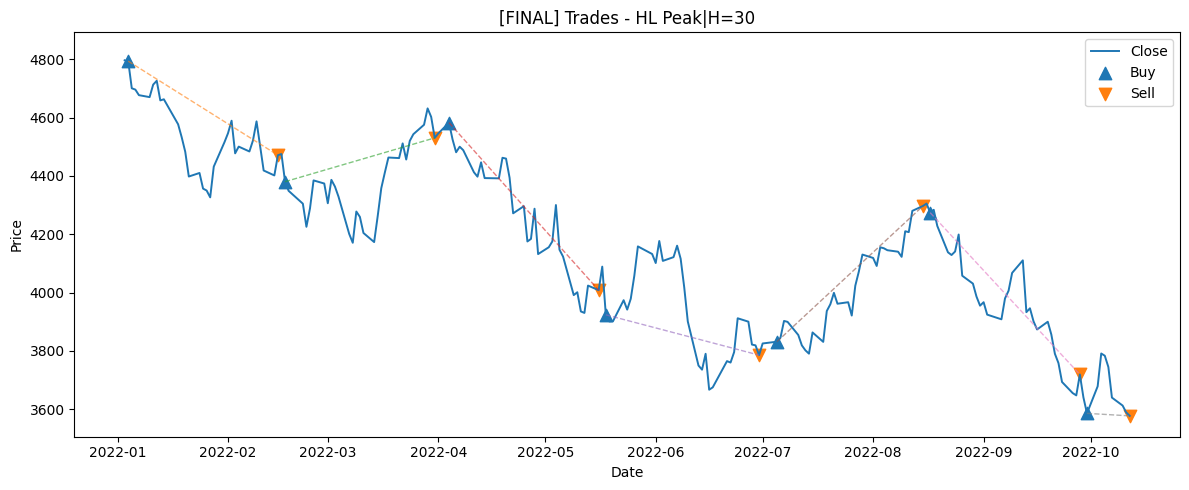

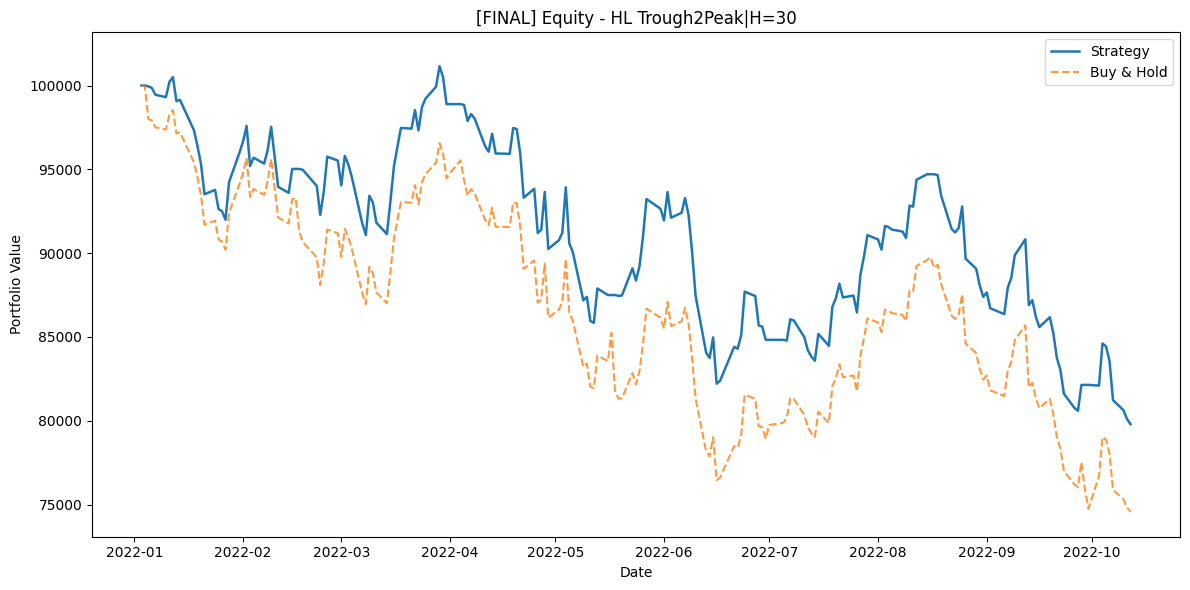

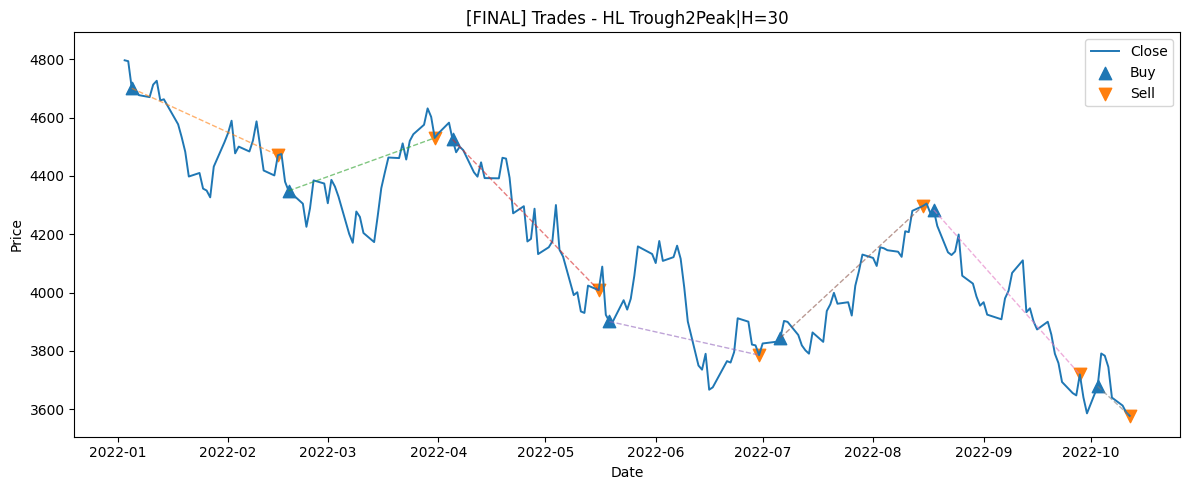

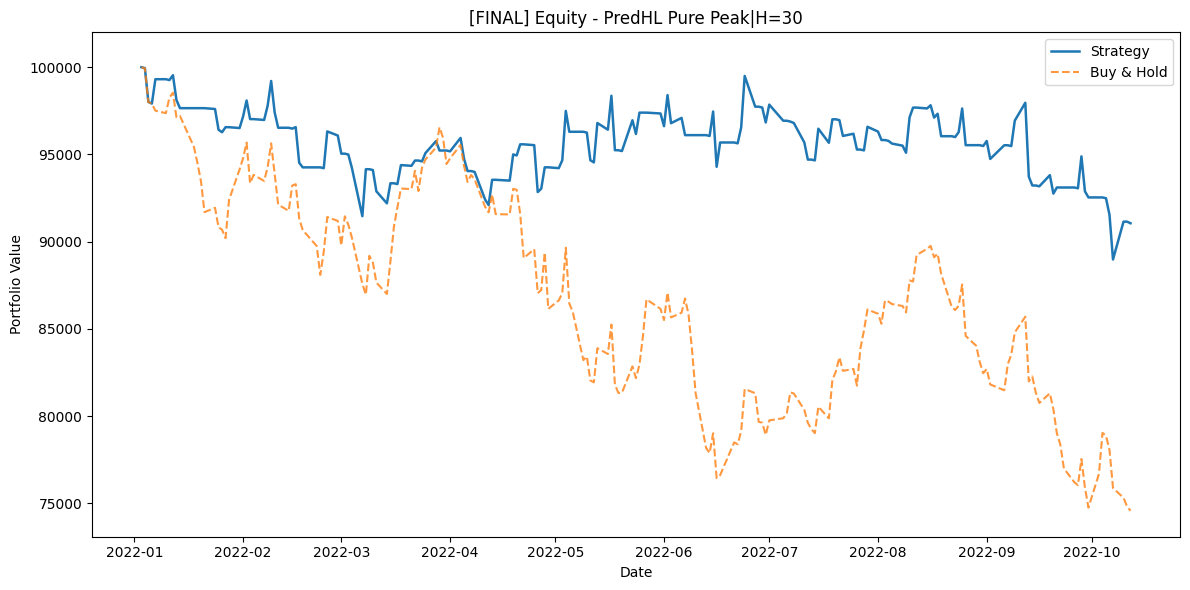

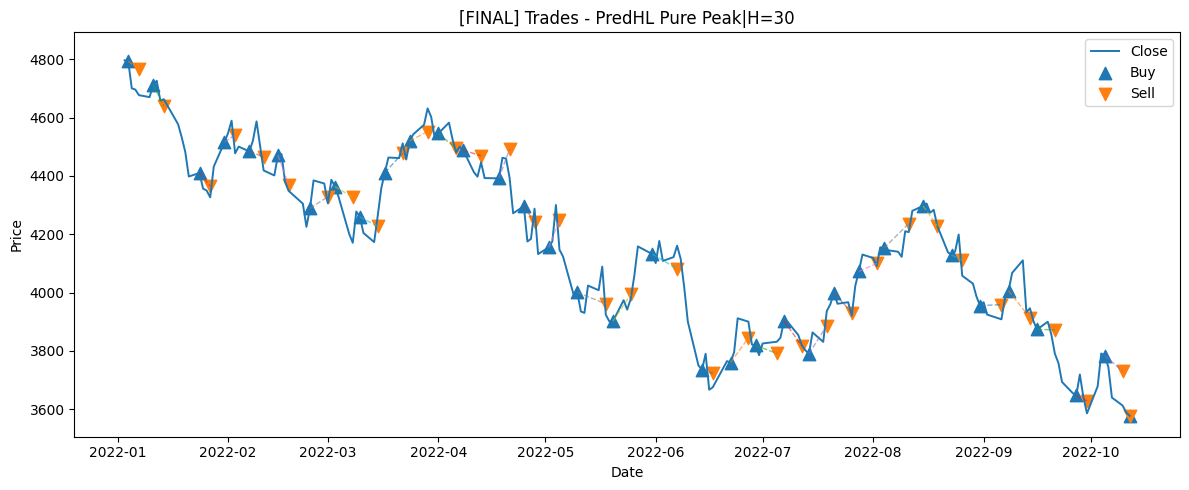

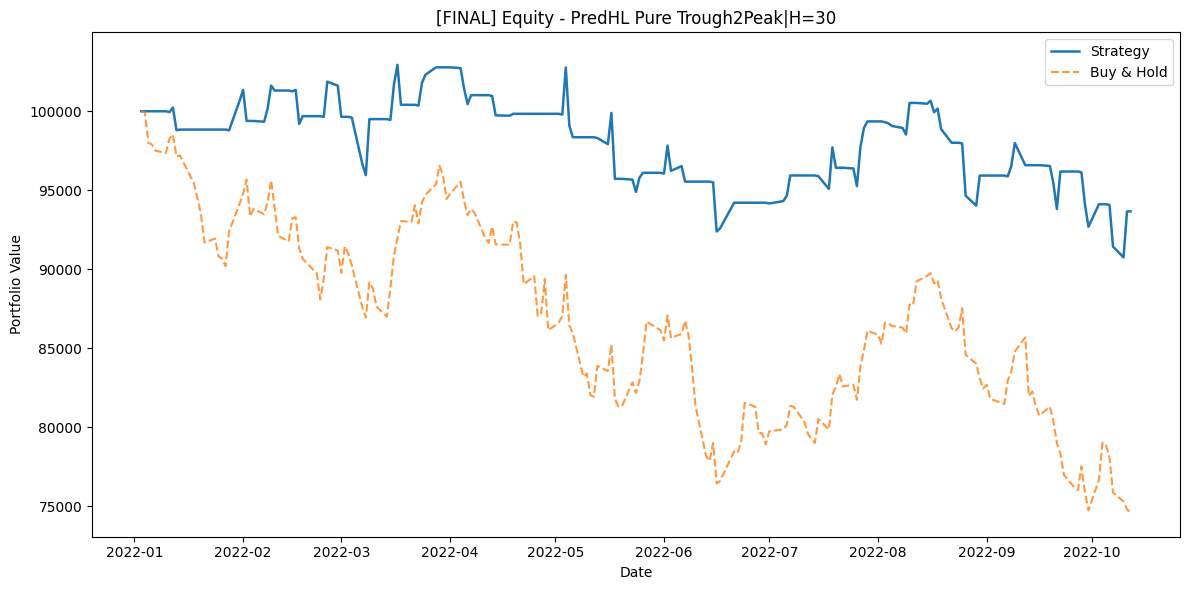

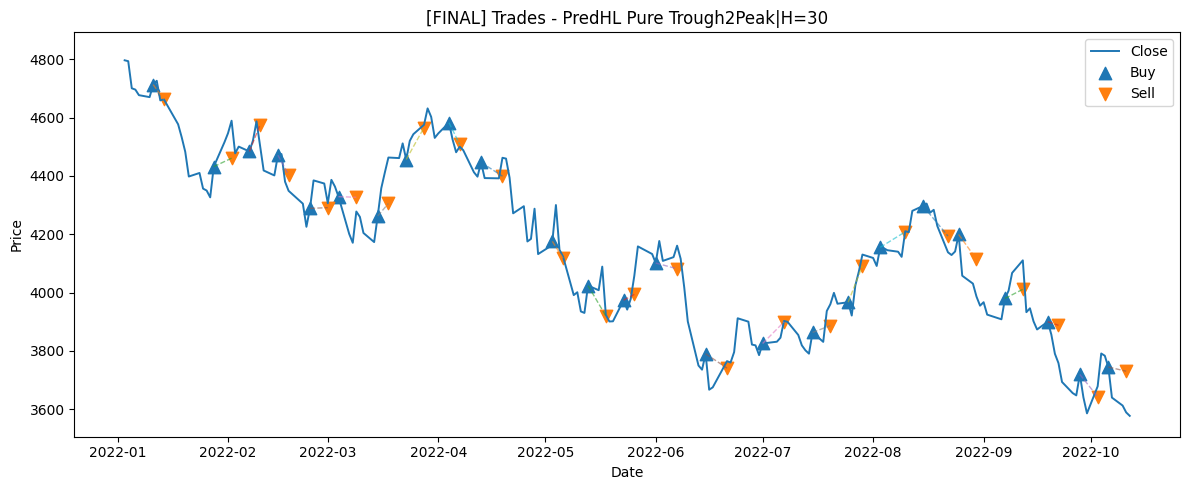

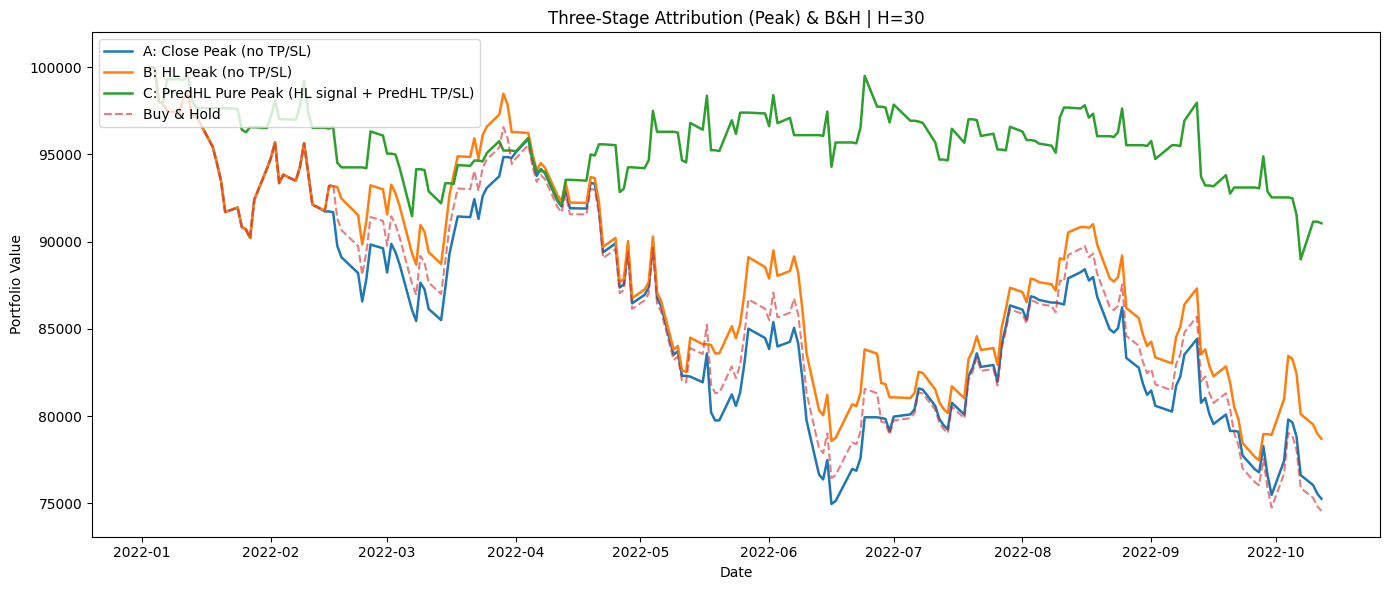


[FINAL COMPARISON] Peak H=30
Metric                   A.Close Peak        B.HL Peak    C.PredHL Pure   B-A(Signal)  C-B(RiskCtrl)   C-A(Total)
------------------------------------------------------------------------------------------------------------------
TotalReturn(%)                 -24.74           -21.30            -8.95         +3.44         +12.35       +15.79
CAGR(%)                        -30.80           -26.68           -11.43         +4.12         +15.25       +19.37
Sharpe                          -1.45            -1.22            -0.62         +0.23          +0.60        +0.83
Sortino                         -1.88            -1.62            -0.83         +0.26          +0.79        +1.05
Calmar                          -1.23            -1.18            -1.04         +0.05          +0.14        +0.19
MaxDrawdown(%)                 -25.04           -22.52           -11.02         +2.52         +11.50       +14.02
ProfitFactor                     0.31             0.42   

In [ ]:
#step4
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Liberation Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore", message=r"Glyph .* missing from font\(s\)")

EVAL_SPLIT      = "test"
SELECT_BY       = "Sharpe"
FINAL_STRATEGY  = None
FINAL_K         = None

HOLDS           = [30]

ENTRY_LAG       = 1
ENTRY_WHERE     = "close"
EXIT_WHERE      = "close"
MIN_HOLD_DAYS_LIST = [1, 2, 3, 5]
MIN_HOLD_DAYS      = MIN_HOLD_DAYS_LIST[0]
ALLOW_OVERLAP   = False

INITIAL_CAPITAL = 100_000.0
FEE_BPS         = 0.0
SLIPPAGE_BPS    = 5
RISK_FREE_RATE  = 0.0

PLOT_WHAT       = "both"

TP_BUFFER_BPS   = 10
SL_BUFFER_BPS   = 10
SAME_DAY_PRIORITY = "sl"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

COST_MODEL          = "static"
SLIPPAGE_BPS_BASE   = SLIPPAGE_BPS
SLIPPAGE_BPS_K_ATR  = 50.0

POSITION_SIZING     = "all_in"
RISK_PER_TRADE_PCT  = 0.02
ATR_N               = 14
ATR_MULT_STOP       = 2.0

USE_POS_SCALE       = True
POS_SCALE_MAX       = None

VALID_STRATEGY_NAMES = {
    "Close Peak", "Close Trough2Peak",
    "HL Peak", "HL Trough2Peak",
    "PredHL Pure Peak", "PredHL Pure Trough2Peak",
}

OOS_STRESS_TEST = True
OOS_START       = "2022-01-03"
OOS_END         = "2022-10-12"

if len(GLOBAL_MODELS) == 0:
    raise RuntimeError("GLOBAL_MODELS not found. Please finish Step 3 first.")

assert MIN_HOLD_DAYS >= 1
assert FEE_BPS >= 0 and SLIPPAGE_BPS >= 0
assert ENTRY_WHERE.lower() in ("open", "close")
assert EXIT_WHERE.lower()  in ("open", "close")
assert EVAL_SPLIT in ("val", "test")

candidates = sorted(GLOBAL_MODELS.keys(), key=lambda k: (k[1], k[0]))
max_hold   = max(HOLDS)
picked     = None
for (L_, H_) in candidates:
    if H_ >= max_hold:
        picked = (L_, H_)
        break
if picked is None:
    picked = candidates[-1]
    print(f"[WARN] 沒有 H >= {max_hold} 的模型，退而使用 {picked}；"
          f"請確認 HOLDS={HOLDS} 不超過模型 H={picked[1]}。")
L_CHOSEN, H_CHOSEN = picked
print(f"[INFO] Using model: L={L_CHOSEN}, H={H_CHOSEN}; HOLDS={HOLDS}")

for K in HOLDS:
    if K > H_CHOSEN:
        print(f"[WARN] HOLDS 中的 K={K} 超過模型 H={H_CHOSEN}，"
              f"超出部分的預測步數不存在，策略結果不可信。請調整 HOLDS。")

model   = GLOBAL_MODELS[(L_CHOSEN, H_CHOSEN)].to(device).eval()
scalers = GLOBAL_SCALERS[(L_CHOSEN, H_CHOSEN)]

if EVAL_SPLIT == "val":
    if 'GLOBAL_DL_VAL' not in globals() or (L_CHOSEN, H_CHOSEN) not in GLOBAL_DL_VAL:
        raise RuntimeError("GLOBAL_DL_VAL missing. Please modify Step 3 to store dl_val.")
    dl_used = GLOBAL_DL_VAL[(L_CHOSEN, H_CHOSEN)]
else:
    dl_used = GLOBAL_DL_TEST[(L_CHOSEN, H_CHOSEN)]


def _standardize_ohlcv_cols(df: pd.DataFrame) -> pd.DataFrame:
    lower = {c: str(c).strip().lower() for c in df.columns}
    def _pick(cands):
        for c in df.columns:
            if lower[c] in cands: return c
        for c in df.columns:
            for k in cands:
                if k in lower[c]: return c
        return None
    c_date   = _pick({"date","datetime","timestamp","time"})
    c_open   = _pick({"open"})
    c_high   = _pick({"high"})
    c_low    = _pick({"low"})
    c_close  = _pick({"close","adj close","adj_close","close*"})
    c_volume = _pick({"volume","vol"})

    out = pd.DataFrame(index=df.index)
    out["Date"] = (pd.to_datetime(df[c_date], errors="coerce")
                   if c_date else
                   pd.to_datetime(range(len(df)), unit="D", origin="1970-01-01"))
    if c_close is None:
        raise ValueError("CSV missing close/adj close column")
    out["Close"]  = pd.to_numeric(df[c_close],  errors="coerce")
    out["Open"]   = pd.to_numeric(df[c_open],   errors="coerce") if c_open   else out["Close"].copy()
    out["High"]   = pd.to_numeric(df[c_high],   errors="coerce") if c_high   else out["Close"].copy()
    out["Low"]    = pd.to_numeric(df[c_low],    errors="coerce") if c_low    else out["Close"].copy()
    if c_volume:
        out["Volume"] = pd.to_numeric(df[c_volume], errors="coerce")
    out["Open"] = out["Open"].fillna(out["Close"])
    out = out.dropna(subset=["Open","High","Low","Close"]).sort_values("Date").reset_index(drop=True)
    return out


def _px(row, which="close") -> float:
    w = which.lower()
    if w == "open":  return float(row["Open"])
    if w == "close": return float(row["Close"])
    if w == "high":  return float(row["High"])
    if w == "low":   return float(row["Low"])
    raise ValueError(f"which must be open/close/high/low, got '{which}'")


def _calc_atr(df: pd.DataFrame, n: int = ATR_N) -> pd.Series:
    h, l, c = df["High"].values, df["Low"].values, df["Close"].values
    prev_c = np.roll(c, 1); prev_c[0] = c[0]
    tr  = np.maximum.reduce([h - l, np.abs(h - prev_c), np.abs(l - prev_c)])
    atr = pd.Series(pd.Series(tr).rolling(n, min_periods=1).mean().values, index=df.index)
    return atr


def _dynamic_slippage_bps(atr_series: pd.Series, close_series: pd.Series) -> pd.Series:
    atr_pct = (atr_series / close_series).replace(0, np.nan).fillna(0.0) * 100.0
    out = (SLIPPAGE_BPS_BASE + SLIPPAGE_BPS_K_ATR * atr_pct).astype(float)
    assert (out >= 0).all()
    return out


def enforce_ohlc_physical_constraints(
    high: np.ndarray, low: np.ndarray,
    close: np.ndarray, open_: np.ndarray
):
    H = np.asarray(high,  dtype=np.float64)
    L = np.asarray(low,   dtype=np.float64)
    C = np.asarray(close, dtype=np.float64)
    O = np.asarray(open_, dtype=np.float64)
    if O.ndim == 2 and O.shape[1] == 1:
        O = np.repeat(O, C.shape[1], axis=1)
    H_corr = np.maximum(H, np.maximum(O, C))
    L_corr = np.minimum(L, np.minimum(O, C))
    return H_corr, L_corr, C


def _inverse_y_block_hl(y_z: np.ndarray, sc, base0: np.ndarray) -> np.ndarray:
    def inv1(yz, col):
        return sc.y_scalers[col].inverse_transform(
            yz.reshape(-1, 1)).reshape(yz.shape)

    ycols = list(sc.y_cols)
    jH, jL = ycols.index("High"), ycols.index("Low")
    rel_H = inv1(y_z[..., jH], "High")
    rel_L = inv1(y_z[..., jL], "Low")
    N, H  = rel_H.shape

    if "Close" in ycols:
        jC    = ycols.index("Close")
        rel_C = inv1(y_z[..., jC], "Close")
        base_seq = np.empty((N, H), dtype=np.float64)
        cur = base0.astype(np.float64).copy()
        for h in range(H):
            base_seq[:, h] = cur
            cur = cur * (1.0 + rel_C[:, h]) if sc.relative_def == "ratio" else cur + rel_C[:, h]
    else:
        base_seq = np.repeat(base0[:, None], H, axis=1)

    out = np.empty((N, H, 2), dtype=np.float64)
    if sc.relative_def == "ratio":
        out[..., 0] = base_seq * (1.0 + rel_H)
        out[..., 1] = base_seq * (1.0 + rel_L)
    else:
        out[..., 0] = base_seq + rel_H
        out[..., 1] = base_seq + rel_L
    return out


def _inverse_close_block(y_z: np.ndarray, sc, base0: np.ndarray) -> np.ndarray:
    def inv1(yz, col):
        return sc.y_scalers[col].inverse_transform(
            yz.reshape(-1, 1)).reshape(yz.shape)

    ycols = list(sc.y_cols)
    jC    = ycols.index("Close")
    rel_C = inv1(y_z[..., jC], "Close")
    N, H  = rel_C.shape
    out   = np.empty((N, H), dtype=np.float64)
    cur   = base0.astype(np.float64).copy()
    for h in range(H):
        cur = cur * (1.0 + rel_C[:, h]) if sc.relative_def == "ratio" else cur + rel_C[:, h]
        out[:, h] = cur
    return out


try:
    full_df = pd.read_csv(CSV_PATH, sep="|")
except Exception:
    full_df = pd.read_csv(CSV_PATH)
full_df = _standardize_ohlcv_cols(full_df)

ds      = dl_used.dataset
t_list  = list(ds.indices)
dates_t = ds.dates.iloc[t_list].reset_index(drop=True)

pred_df = dates_t.to_frame(name="Date").merge(full_df, on="Date", how="left", sort=False)
if pred_df.isnull().any().any():
    raise RuntimeError(f"Found {pred_df.isnull().any(axis=1).sum()} missing rows when aligning by Date.")
pred_df = pred_df.reset_index(drop=True)
print(f"[ALIGN] pred_df ready: N={len(pred_df)}, "
      f"range {pred_df['Date'].min()} ~ {pred_df['Date'].max()}")

all_pred_hl_blocks, all_pred_close_blocks = [], []
cursor = 0

with torch.no_grad():
    for x_hist, _y_seq in dl_used:
        x_hist   = x_hist.to(device)
        y_hat    = model.predict(x_hist, H_CHOSEN)
        y_hat_np = y_hat.detach().cpu().numpy()
        B        = y_hat_np.shape[0]

        pred_batch = pred_df.iloc[cursor:cursor + B]
        if len(pred_batch) != B:
            raise RuntimeError(f"Batch misalignment: cursor={cursor}, B={B}")

        base0      = pred_batch["Close"].to_numpy(dtype=np.float64)
        open_base  = pred_batch["Open"].to_numpy(dtype=np.float64)[:, None]
        cursor    += B

        y_hat_hl_raw    = _inverse_y_block_hl(y_hat_np, scalers, base0)
        y_hat_close_raw = _inverse_close_block(y_hat_np, scalers, base0)

        H_corr, L_corr, C_corr = enforce_ohlc_physical_constraints(
            y_hat_hl_raw[..., 0], y_hat_hl_raw[..., 1],
            y_hat_close_raw, open_base
        )
        all_pred_hl_blocks.append(np.stack([H_corr, L_corr], axis=-1))
        all_pred_close_blocks.append(C_corr)

assert cursor == len(pred_df), f"Cursor mismatch: cursor={cursor}, pred_df={len(pred_df)}"

P_raw   = np.concatenate(all_pred_hl_blocks,   axis=0)
P_close = np.concatenate(all_pred_close_blocks, axis=0)

assert P_raw.shape[0] == len(pred_df) == P_close.shape[0]
assert P_raw.shape[1] == P_close.shape[1]

idxH, idxL = 0, 1
print("[OK] Inference blocks aligned: P_raw", P_raw.shape, "P_close", P_close.shape)

if OOS_STRESS_TEST:
    pred_df = pred_df[
        (pred_df["Date"] >= pd.Timestamp(OOS_START)) &
        (pred_df["Date"] <= pd.Timestamp(OOS_END))
    ].reset_index(drop=True)

    _oos_mask = (
        (dates_t >= pd.Timestamp(OOS_START)) &
        (dates_t <= pd.Timestamp(OOS_END))
    ).values

    P_raw   = P_raw[_oos_mask]
    P_close = P_close[_oos_mask]

    print(f"[STRESS TEST] {OOS_START} ~ {OOS_END}: N={len(pred_df)}")
    assert len(pred_df) == P_raw.shape[0] == P_close.shape[0], "OOS filter mismatch"
else:
    print(f"[INFO] No date filter applied, using full {EVAL_SPLIT} split.")

ATR_SER_RAW   = _calc_atr(pred_df, ATR_N)
ATR_SER_ENTRY = ATR_SER_RAW.copy()

if COST_MODEL == "atr_dynamic":
    DYN_SLIPPAGE_BPS_RAW   = _dynamic_slippage_bps(ATR_SER_RAW, pred_df["Close"])
    DYN_SLIPPAGE_BPS_ENTRY = DYN_SLIPPAGE_BPS_RAW.copy()
    DYN_SLIPPAGE_BPS_EXIT  = DYN_SLIPPAGE_BPS_RAW.copy()
else:
    DYN_SLIPPAGE_BPS_ENTRY = None
    DYN_SLIPPAGE_BPS_EXIT  = None


@dataclass
class TradePlan:
    entry_idx: int; exit_idx: int
    entry_date: pd.Timestamp; exit_date: pd.Timestamp
    entry_price: float; exit_price: float
    holding_days: int; horizon_limit: int
    reason: str; ret_pct: float


def backtest_plan_close_only(
    df: pd.DataFrame, P_close_sig: np.ndarray, hold: int,
    mode: str = "close_peak",
    entry_lag: int = 1, min_hold_days: int = 1,
    allow_overlap: bool = False
) -> pd.DataFrame:
    df = df.reset_index(drop=True).copy()
    n = len(df); trades = []; i = 0; last_exit = -1

    while i < n - 1:
        if not allow_overlap and last_exit >= 0 and i <= last_exit:
            i = last_exit + 1; continue
        if i >= len(P_close_sig): break

        if mode == "close_peak":
            k_entry = entry_lag
            k_exit  = min(int(np.argmax(P_close_sig[i, :hold])) + 1, hold)
        elif mode == "close_trough2peak":
            k_min   = int(np.argmin(P_close_sig[i, :hold])) + 1
            k_entry = max(k_min, entry_lag + 1)
            if k_entry < hold:
                window = P_close_sig[i, k_entry:hold]
                k_exit = min(k_entry + int(np.argmax(window)) + 1, hold)
            else:
                k_exit = hold
        else:
            i += 1; continue

        entry_idx = i + k_entry
        exit_idx  = i + k_exit
        if entry_idx >= n: break

        last_idx = min(i + hold, n - 1)
        exit_idx = min(exit_idx, last_idx)
        if exit_idx - entry_idx < min_hold_days:
            exit_idx = min(max(entry_idx + min_hold_days, exit_idx), last_idx)
            if exit_idx <= entry_idx: i += 1; continue

        entry_bar   = df.loc[entry_idx]
        exit_bar    = df.loc[exit_idx]
        entry_price = float(entry_bar["Close"])
        exit_price  = float(exit_bar["Close"])

        trades.append(TradePlan(
            entry_idx, exit_idx, entry_bar["Date"], exit_bar["Date"],
            entry_price, exit_price, int(exit_idx - entry_idx), hold,
            "CLOSE_PEAK" if mode == "close_peak" else "CLOSE_T2P",
            (exit_price / entry_price - 1.0) * 100.0
        ))
        last_exit = exit_idx
        i = exit_idx if not allow_overlap else i + 1

    out = pd.DataFrame([t.__dict__ for t in trades])
    if not out.empty:
        out["ret_mult"]  = out["exit_price"] / out["entry_price"]
        out["cum_mult"]  = out["ret_mult"].cumprod()
        out["win"]       = (out["ret_pct"] > 0).astype(int)
        out["pos_scale"] = 1.0
    return out


def backtest_plan_hl_only(
    df: pd.DataFrame, P_raw_sig: np.ndarray, hold: int,
    mode: str = "hl_peak",
    entry_lag: int = 1, min_hold_days: int = 1,
    allow_overlap: bool = False,
    idx_high: int = 0, idx_low: int = 1,
) -> pd.DataFrame:
    df = df.reset_index(drop=True).copy()
    n = len(df); trades = []; i = 0; last_exit = -1

    while i < n - 1:
        if not allow_overlap and last_exit >= 0 and i <= last_exit:
            i = last_exit + 1; continue
        if i >= len(P_raw_sig): break

        if mode == "hl_peak":
            k_entry = entry_lag
            k_exit  = min(int(np.argmax(P_raw_sig[i, :hold, idx_high])) + 1, hold)
        elif mode == "hl_trough2peak":
            k_min   = int(np.argmin(P_raw_sig[i, :hold, idx_low])) + 1
            k_entry = max(k_min, entry_lag + 1)
            if k_entry < hold:
                window = P_raw_sig[i, k_entry:hold, idx_high]
                k_exit = min(k_entry + int(np.argmax(window)) + 1, hold)
            else:
                k_exit = hold
        else:
            i += 1; continue

        entry_idx = i + k_entry
        exit_idx  = i + k_exit
        if entry_idx >= n: break

        last_idx = min(i + hold, n - 1)
        exit_idx = min(exit_idx, last_idx)
        if exit_idx - entry_idx < min_hold_days:
            exit_idx = min(max(entry_idx + min_hold_days, exit_idx), last_idx)
            if exit_idx <= entry_idx: i += 1; continue

        entry_bar   = df.loc[entry_idx]
        exit_bar    = df.loc[exit_idx]
        entry_price = float(entry_bar["Close"])
        exit_price  = float(exit_bar["Close"])

        trades.append(TradePlan(
            entry_idx, exit_idx, entry_bar["Date"], exit_bar["Date"],
            entry_price, exit_price, int(exit_idx - entry_idx), hold,
            "HL_PEAK" if mode == "hl_peak" else "HL_T2P",
            (exit_price / entry_price - 1.0) * 100.0
        ))
        last_exit = exit_idx
        i = exit_idx if not allow_overlap else i + 1

    out = pd.DataFrame([t.__dict__ for t in trades])
    if not out.empty:
        out["ret_mult"]  = out["exit_price"] / out["entry_price"]
        out["cum_mult"]  = out["ret_mult"].cumprod()
        out["win"]       = (out["ret_pct"] > 0).astype(int)
        out["pos_scale"] = 1.0
    return out


def backtest_plan_predhl_pure(
    df: pd.DataFrame, P_raw_sig: np.ndarray, hold: int,
    mode: str = "trough_then_peak",
    entry_where: str = "close", entry_lag: int = 1,
    min_hold_days: int = 1, allow_overlap: bool = False,
    idx_high: int = 0, idx_low: int = 1,
    tp_buffer_bps: float = TP_BUFFER_BPS,
    sl_buffer_bps: float = SL_BUFFER_BPS,
    same_day_priority: str = SAME_DAY_PRIORITY,
) -> pd.DataFrame:
    df = df.reset_index(drop=True).copy()
    n  = len(df); trades = []; i = 0; last_exit = -1
    skipped_no_signal = 0

    while i < n - 1:
        if not allow_overlap and last_exit >= 0 and i <= last_exit:
            i = last_exit + 1; continue
        if i >= len(P_raw_sig): break

        if mode == "sell_at_peak":
            k_entry     = entry_lag
            k_exit_plan = min(int(np.argmax(P_raw_sig[i, :hold, idx_high])) + 1, hold)
        else:
            k_min       = int(np.argmin(P_raw_sig[i, :hold, idx_low])) + 1
            k_entry     = max(k_min, entry_lag + 1)
            if k_entry < hold:
                window      = P_raw_sig[i, k_entry:hold, idx_high]
                k_exit_plan = min(k_entry + int(np.argmax(window)) + 1, hold)
            else:
                k_exit_plan = hold

        entry_idx_plan = i + k_entry
        exit_idx_plan  = i + k_exit_plan
        if entry_idx_plan >= n: break

        entry_bar   = df.loc[entry_idx_plan]
        entry_price = _px(entry_bar, entry_where)

        sub_start = max(0, k_entry - 1)
        sub_end   = min(k_exit_plan, hold)

        if sub_start >= sub_end:
            skipped_no_signal += 1
            i += 1; continue

        pred_high_max = float(np.max(P_raw_sig[i, sub_start:sub_end, idx_high]))
        pred_low_min  = float(np.min(P_raw_sig[i, sub_start:sub_end, idx_low]))

        if pred_high_max <= entry_price:
            skipped_no_signal += 1
            i += 1; continue

        if pred_low_min >= entry_price:
            skipped_no_signal += 1
            i += 1; continue

        tp_price = pred_high_max * (1.0 - tp_buffer_bps / 1e4)
        sl_price = pred_low_min  * (1.0 + sl_buffer_bps / 1e4)

        if tp_price <= sl_price:
            skipped_no_signal += 1
            i += 1; continue

        executed      = False
        last_idx      = min(i + hold, n - 1)
        earliest_exit = min(last_idx, entry_idx_plan + min_hold_days)

        for d in range(entry_idx_plan, last_idx + 1):
            if d < earliest_exit: continue
            day_high = float(df.loc[d, "High"])
            day_low  = float(df.loc[d, "Low"])
            hit_tp   = day_high >= tp_price
            hit_sl   = day_low  <= sl_price
            if not (hit_tp or hit_sl): continue

            if hit_tp and hit_sl:
                exit_price = sl_price if same_day_priority.lower() == "sl" else tp_price
                reason     = "PURE_SL_SAME" if same_day_priority.lower() == "sl" else "PURE_TP_SAME"
            elif hit_tp:
                exit_price = tp_price; reason = "PURE_TP"
            else:
                exit_price = sl_price; reason = "PURE_SL"

            trades.append(TradePlan(
                entry_idx_plan, d, entry_bar["Date"], df.loc[d, "Date"],
                float(entry_price), float(exit_price),
                int(d - entry_idx_plan), hold, reason,
                (exit_price / entry_price - 1.0) * 100.0
            ).__dict__ | {
                "pos_scale":        1.0,
                "pred_tp_price":    tp_price,
                "pred_sl_price":    sl_price,
                "pred_tp_dist_pct": (tp_price / entry_price - 1.0) * 100.0,
                "pred_sl_dist_pct": (sl_price / entry_price - 1.0) * 100.0,
            })
            last_exit = d; executed = True; break

        if not executed:
            exit_idx   = min(exit_idx_plan, last_idx)
            exit_price = _px(df.loc[exit_idx], EXIT_WHERE)
            trades.append(TradePlan(
                entry_idx_plan, exit_idx, entry_bar["Date"], df.loc[exit_idx, "Date"],
                float(entry_price), float(exit_price),
                int(exit_idx - entry_idx_plan), hold, "PURE_NONE",
                (exit_price / entry_price - 1.0) * 100.0
            ).__dict__ | {
                "pos_scale":        1.0,
                "pred_tp_price":    tp_price,
                "pred_sl_price":    sl_price,
                "pred_tp_dist_pct": (tp_price / entry_price - 1.0) * 100.0,
                "pred_sl_dist_pct": (sl_price / entry_price - 1.0) * 100.0,
            })
            last_exit = exit_idx

        i = last_exit if not allow_overlap else i + 1

    out = pd.DataFrame(trades)
    if not out.empty:
        out["ret_mult"] = out["exit_price"] / out["entry_price"]
        out["cum_mult"] = out["ret_mult"].cumprod()
        out["win"]      = (out["ret_pct"] > 0).astype(int)

        print(f"\n[{mode}] === PredHL Pure 診斷 ===")
        print(f"  有效交易筆數 : {len(out)}")
        print(f"  跳過信號筆數 : {skipped_no_signal}（預測邊界不合理或子視窗退化）")
        print(f"  Exit reason  :\n{out['reason'].value_counts().to_string()}")
        print(f"  預測 TP 距離 : mean={out['pred_tp_dist_pct'].mean():.2f}%  "
              f"median={out['pred_tp_dist_pct'].median():.2f}%")
        print(f"  預測 SL 距離 : mean={out['pred_sl_dist_pct'].mean():.2f}%  "
              f"median={out['pred_sl_dist_pct'].median():.2f}%")
        print(f"  平均持有天數 : {out['holding_days'].mean():.1f}")

    return out


def equity_curve_from_trades(
    trades: pd.DataFrame, df: pd.DataFrame,
    initial_capital: float = INITIAL_CAPITAL,
    fee_bps: float = FEE_BPS,
    slippage_bps: float = SLIPPAGE_BPS,
    atr_series_entry: Optional[pd.Series] = None,
    dyn_slip_bps_entry: Optional[pd.Series] = None,
    dyn_slip_bps_exit:  Optional[pd.Series] = None
) -> pd.DataFrame:

    def _side_entry(idx):
        slip = float(dyn_slip_bps_entry.iloc[idx]) if dyn_slip_bps_entry is not None else slippage_bps
        return (fee_bps + slip) / 1e4

    def _side_exit(idx):
        slip = float(dyn_slip_bps_exit.iloc[idx]) if dyn_slip_bps_exit is not None else slippage_bps
        return (fee_bps + slip) / 1e4

    def _risk_shares(cap_now, px_cost, i_entry):
        if atr_series_entry is None or np.isnan(atr_series_entry.iloc[i_entry]):
            return cap_now / px_cost
        stop = ATR_MULT_STOP * float(atr_series_entry.iloc[i_entry])
        if stop <= 0: return cap_now / px_cost
        return float(max(0.0, min(cap_now * RISK_PER_TRADE_PCT / stop, cap_now / px_cost)))

    entry_map = {}; exit_map = {}; pos_scale_map = {}
    if trades is not None and not trades.empty:
        for _, r in trades.iterrows():
            ei = int(r.entry_idx); xi = int(r.exit_idx)
            entry_map[ei]     = float(r.entry_price)
            exit_map[xi]      = float(r.exit_price)
            ps = 1.0
            try:   ps = float(r.get("pos_scale", 1.0))
            except: pass
            if POS_SCALE_MAX is not None: ps = min(ps, float(POS_SCALE_MAX))
            pos_scale_map[ei] = ps

    cap    = initial_capital
    equity = np.full(len(df), np.nan)
    pos    = False; shares = 0.0

    for i in range(len(df)):
        c_close = float(df.loc[i, "Close"])
        if i in entry_map and not pos:
            px_cost = entry_map[i] * (1 + _side_entry(i))
            base_sh = _risk_shares(cap, px_cost, i) if POSITION_SIZING == "atr_risk" else (cap / px_cost)
            scale   = float(pos_scale_map.get(i, 1.0)) if USE_POS_SCALE else 1.0
            sh      = base_sh * max(0.0, scale)
            if px_cost > 0 and sh > 0:
                shares = sh; cap -= shares * px_cost; pos = True
        if i in exit_map and pos:
            cap   += shares * exit_map[i] * (1 - _side_exit(i))
            shares = 0.0; pos = False
        equity[i] = cap + (shares * c_close if pos else 0.0)

    return pd.DataFrame({"Date": df["Date"], "equity": pd.Series(equity).ffill()})


def _downside_std(rets: pd.Series, rf: float = 0.0) -> float:
    rets = rets.dropna()
    if rets.empty: return 0.0
    d = np.minimum(0.0, rets - rf / 252.0)
    return float(np.sqrt((d**2).mean()))


def calculate_performance_metrics(
    equity_df: pd.DataFrame, full_price_df: pd.DataFrame,
    risk_free_rate: float = RISK_FREE_RATE,
    trading_days_per_year: int = 252
) -> Dict[str, float]:
    equity_df = equity_df.dropna()
    if equity_df.empty or len(equity_df) < 2:
        return {"TotalReturn(%)": 0.0, "B&H(%)": 0.0, "MaxDrawdown(%)": 0.0,
                "Sharpe": 0.0, "CAGR(%)": 0.0, "Sortino": 0.0, "Calmar": 0.0}

    init_eq = float(equity_df["equity"].iloc[0])
    fin_eq  = float(equity_df["equity"].iloc[-1])
    total_ret_pct = (fin_eq / init_eq - 1.0) * 100.0

    s_date = equity_df["Date"].iloc[0]; e_date = equity_df["Date"].iloc[-1]
    bnh = full_price_df[(full_price_df["Date"] >= s_date) & (full_price_df["Date"] <= e_date)]
    bnh_ret = 0.0
    if not bnh.empty:
        bnh_ret = (float(bnh["Close"].iloc[-1]) / float(bnh["Close"].iloc[0]) - 1.0) * 100.0

    running_max = equity_df["equity"].cummax()
    max_dd_pct  = float(((equity_df["equity"] - running_max) / running_max).min() * 100.0)
    daily_ret   = equity_df["equity"].pct_change().dropna()
    mu  = float(daily_ret.mean()) if len(daily_ret) else 0.0
    sd  = float(daily_ret.std())  if len(daily_ret) > 1 else 0.0
    sharpe  = 0.0 if (sd == 0 or np.isnan(sd)) else (mu * trading_days_per_year - risk_free_rate) / (sd * np.sqrt(trading_days_per_year))
    years   = max(1, int((pd.to_datetime(e_date) - pd.to_datetime(s_date)).days)) / 365.25
    cagr    = (fin_eq / init_eq) ** (1 / years) - 1.0
    dstd    = _downside_std(daily_ret, risk_free_rate)
    sortino = 0.0 if dstd == 0 else (mu * trading_days_per_year - risk_free_rate) / (dstd * np.sqrt(trading_days_per_year))
    calmar  = 0.0 if (cagr == 0 or max_dd_pct == 0) else cagr / (abs(max_dd_pct) / 100.0)

    return {
        "TotalReturn(%)": round(total_ret_pct, 2), "B&H(%)": round(bnh_ret, 2),
        "MaxDrawdown(%)": round(max_dd_pct, 2),    "Sharpe": round(sharpe, 2),
        "CAGR(%)": round(cagr * 100.0, 2),         "Sortino": round(sortino, 2),
        "Calmar": round(calmar, 2),
    }


def _compute_net_trade_returns(
    trades: pd.DataFrame,
    fee_bps: float, slippage_bps: float,
    dyn_slip_bps_entry: Optional[pd.Series],
    dyn_slip_bps_exit:  Optional[pd.Series]
) -> pd.Series:
    if trades is None or trades.empty: return pd.Series(dtype=float)
    def side(ser, idx):
        v = float(ser.iloc[int(idx)]) if ser is not None else slippage_bps
        return (fee_bps + v) / 1e4
    nets = []
    for _, r in trades.iterrows():
        pe = float(r.entry_price) * (1.0 + side(dyn_slip_bps_entry, r.entry_idx))
        px = float(r.exit_price)  * (1.0 - side(dyn_slip_bps_exit,  r.exit_idx))
        nets.append((px / pe - 1.0) * 100.0)
    return pd.Series(nets, index=trades.index, dtype=float)


def summarize_trades(trades: pd.DataFrame) -> Dict[str, float]:
    empty = {"trades": 0, "winrate_%": 0.0, "avg_ret_%": 0.0, "median_ret_%": 0.0,
             "best_ret_%": 0.0, "worst_ret_%": 0.0, "cum_return_%": 0.0,
             "profit_factor": 0.0, "avg_hold_days": 0.0}
    if trades is None or trades.empty: return empty

    net = _compute_net_trade_returns(trades, FEE_BPS, SLIPPAGE_BPS,
                                     DYN_SLIPPAGE_BPS_ENTRY, DYN_SLIPPAGE_BPS_EXIT)
    total    = len(trades)
    cum_mult = float(np.prod(1.0 + net.values / 100.0)) if total > 0 else 1.0
    pos = net[net > 0].sum(); neg = -net[net < 0].sum()
    pf  = float(pos / neg) if neg > 0 else (float("inf") if pos > 0 else 0.0)
    avg_hold = float(trades["holding_days"].mean()) if "holding_days" in trades.columns else 0.0

    return {
        "trades":        total,
        "winrate_%":     round(float((net > 0).mean() * 100.0), 2),
        "avg_ret_%":     round(float(net.mean()), 3),
        "median_ret_%":  round(float(net.median()), 3),
        "best_ret_%":    round(float(net.max()), 3),
        "worst_ret_%":   round(float(net.min()), 3),
        "cum_return_%":  round((cum_mult - 1.0) * 100.0, 2),
        "profit_factor": round(pf, 2),
        "avg_hold_days": round(avg_hold, 1),
    }


def collect_summary(
    run_dict: Dict[int, pd.DataFrame],
    mode_name: str,
    full_price_df: pd.DataFrame
) -> List[Dict]:
    rows = []
    for K, trades in run_dict.items():
        if trades is None or trades.empty:
            perf = {"TotalReturn(%)": 0.0, "B&H(%)": 0.0, "CAGR(%)": 0.0,
                    "Sharpe": 0.0, "Sortino": 0.0, "Calmar": 0.0, "MaxDrawdown(%)": 0.0}
            summ = {"profit_factor": 0.0, "winrate_%": 0.0, "trades": 0, "avg_hold_days": 0.0}
        else:
            eq   = equity_curve_from_trades(trades, full_price_df, INITIAL_CAPITAL, FEE_BPS, SLIPPAGE_BPS,
                                            ATR_SER_ENTRY, DYN_SLIPPAGE_BPS_ENTRY, DYN_SLIPPAGE_BPS_EXIT)
            perf = calculate_performance_metrics(eq, full_price_df, RISK_FREE_RATE)
            summ = summarize_trades(trades)
        rows.append({
            "Strategy":       mode_name, "H": K,
            "TotalReturn(%)": perf["TotalReturn(%)"], "B&H(%)":  perf["B&H(%)"],
            "CAGR(%)":        perf["CAGR(%)"],        "Sharpe":  perf["Sharpe"],
            "Sortino":        perf["Sortino"],         "Calmar":  perf["Calmar"],
            "MaxDrawdown(%)": perf["MaxDrawdown(%)"],
            "ProfitFactor":   summ["profit_factor"],
            "WinRate(%)":     summ["winrate_%"],
            "Trades":         summ["trades"],
            "AvgHoldDays":    summ["avg_hold_days"],
        })
    return rows


def _set_ybuffer(y):
    y = np.asarray(y, dtype=float)
    return max(1.0, np.nanmin(y) * 0.98), np.nanmax(y) * 1.02


def plot_equity(equity_df: pd.DataFrame, title: str,
                benchmark_df: Optional[pd.DataFrame] = None):
    dfp = equity_df.dropna()
    if dfp.empty: print("[plot_equity] Empty equity; skip."); return
    plt.figure(figsize=(12, 6))
    plt.plot(dfp["Date"], dfp["equity"], linewidth=1.8, label="Strategy")
    bench_p = None
    if benchmark_df is not None and not benchmark_df.empty:
        bench_p = benchmark_df.dropna().copy()
        bench_p["equity"] = dfp["equity"].iloc[0] * (bench_p["equity"] / bench_p["equity"].iloc[0])
        plt.plot(bench_p["Date"], bench_p["equity"], linewidth=1.5, linestyle="--", alpha=0.8, label="Buy & Hold")
    all_eq = dfp["equity"] if bench_p is None else pd.concat([dfp["equity"], bench_p["equity"]])
    plt.ylim(*_set_ybuffer(all_eq))
    plt.title(title); plt.xlabel("Date"); plt.ylabel("Portfolio Value"); plt.legend()
    plt.tight_layout(); plt.show()


def plot_trades_on_price(df: pd.DataFrame, trades: pd.DataFrame, title: str):
    if df.empty: print("[plot_trades_on_price] Empty df; skip."); return
    plt.figure(figsize=(12, 5))
    plt.plot(df["Date"], df["Close"], label="Close", linewidth=1.4)
    if trades is not None and not trades.empty:
        plt.scatter(trades["entry_date"], trades["entry_price"], marker="^", s=80, label="Buy")
        plt.scatter(trades["exit_date"],  trades["exit_price"],  marker="v", s=80, label="Sell")
        for _, r in trades.iterrows():
            plt.plot([r.entry_date, r.exit_date], [r.entry_price, r.exit_price],
                     linestyle="--", alpha=0.6, linewidth=1.0)
    plt.ylim(*_set_ybuffer(df["Close"]))
    plt.title(title); plt.legend(); plt.xlabel("Date"); plt.ylabel("Price")
    plt.tight_layout(); plt.show()


results_close_peak              = {}
results_close_trough2peak       = {}
results_hl_peak                 = {}
results_hl_trough2peak          = {}
results_predhl_pure_peak        = {}
results_predhl_pure_trough2peak = {}

cols_order = ["Strategy", "H", "TotalReturn(%)", "B&H(%)", "CAGR(%)",
              "Sharpe", "Sortino", "Calmar", "MaxDrawdown(%)",
              "ProfitFactor", "WinRate(%)", "Trades", "AvgHoldDays"]


def _run_one(strategy_name: str, K: int):

    if strategy_name == "Close Peak":
        results_close_peak[K] = backtest_plan_close_only(
            pred_df, P_close, hold=K, mode="close_peak",
            entry_lag=ENTRY_LAG,
            min_hold_days=1,
            allow_overlap=ALLOW_OVERLAP)

    elif strategy_name == "Close Trough2Peak":
        results_close_trough2peak[K] = backtest_plan_close_only(
            pred_df, P_close, hold=K, mode="close_trough2peak",
            entry_lag=ENTRY_LAG,
            min_hold_days=1,
            allow_overlap=ALLOW_OVERLAP)

    elif strategy_name == "HL Peak":
        results_hl_peak[K] = backtest_plan_hl_only(
            pred_df, P_raw, hold=K, mode="hl_peak",
            entry_lag=ENTRY_LAG,
            min_hold_days=1,
            allow_overlap=ALLOW_OVERLAP,
            idx_high=idxH, idx_low=idxL)

    elif strategy_name == "HL Trough2Peak":
        results_hl_trough2peak[K] = backtest_plan_hl_only(
            pred_df, P_raw, hold=K, mode="hl_trough2peak",
            entry_lag=ENTRY_LAG,
            min_hold_days=1,
            allow_overlap=ALLOW_OVERLAP,
            idx_high=idxH, idx_low=idxL)

    elif strategy_name == "PredHL Pure Peak":
        results_predhl_pure_peak[K] = backtest_plan_predhl_pure(
            pred_df, P_raw, hold=K, mode="sell_at_peak",
            entry_where=ENTRY_WHERE, entry_lag=ENTRY_LAG,
            min_hold_days=MIN_HOLD_DAYS, allow_overlap=ALLOW_OVERLAP,
            idx_high=idxH, idx_low=idxL,
            tp_buffer_bps=TP_BUFFER_BPS, sl_buffer_bps=SL_BUFFER_BPS,
            same_day_priority=SAME_DAY_PRIORITY)

    elif strategy_name == "PredHL Pure Trough2Peak":
        results_predhl_pure_trough2peak[K] = backtest_plan_predhl_pure(
            pred_df, P_raw, hold=K, mode="trough_then_peak",
            entry_where=ENTRY_WHERE, entry_lag=ENTRY_LAG,
            min_hold_days=MIN_HOLD_DAYS, allow_overlap=ALLOW_OVERLAP,
            idx_high=idxH, idx_low=idxL,
            tp_buffer_bps=TP_BUFFER_BPS, sl_buffer_bps=SL_BUFFER_BPS,
            same_day_priority=SAME_DAY_PRIORITY)

    else:
        raise ValueError(f"Unknown strategy '{strategy_name}'")


RUN_ALL_STRATEGIES_FOR_STRESS = True

if RUN_ALL_STRATEGIES_FOR_STRESS:
    for K in HOLDS:
        _run_one("Close Peak",              K)
        _run_one("Close Trough2Peak",       K)
        _run_one("HL Peak",                 K)
        _run_one("HL Trough2Peak",          K)
        _run_one("PredHL Pure Peak",        K)
        _run_one("PredHL Pure Trough2Peak", K)
else:
    assert FINAL_STRATEGY is not None and FINAL_K is not None
    assert FINAL_K in HOLDS
    for d in [results_close_peak, results_close_trough2peak,
              results_hl_peak, results_hl_trough2peak,
              results_predhl_pure_peak, results_predhl_pure_trough2peak]:
        d.clear()
    _run_one(FINAL_STRATEGY, int(FINAL_K))
    print(f"[TEST-RUN] Strategy='{FINAL_STRATEGY}', H={FINAL_K}")


summary_rows = []
for name, store in [
    ("Close Peak",              results_close_peak),
    ("Close Trough2Peak",       results_close_trough2peak),
    ("HL Peak",                 results_hl_peak),
    ("HL Trough2Peak",          results_hl_trough2peak),
    ("PredHL Pure Peak",        results_predhl_pure_peak),
    ("PredHL Pure Trough2Peak", results_predhl_pure_trough2peak),
]:
    if store:
        summary_rows += collect_summary(store, name, pred_df)

summary_df = pd.DataFrame(summary_rows)
if not summary_df.empty:
    summary_df = summary_df[[c for c in cols_order if c in summary_df.columns]]

if not summary_df.empty and "AvgHoldDays" in summary_df.columns:
    short_hold = summary_df[summary_df["AvgHoldDays"] <= MIN_HOLD_DAYS + 0.5]
    if not short_hold.empty:
        print("\n[INFO] 以下策略平均持有天數接近最短持有期，表示 TP/SL 在高波動期間快速觸發：")
        print(short_hold[["Strategy", "H", "AvgHoldDays", "Sharpe", "Trades"]].to_string(index=False))

if EVAL_SPLIT == "val":
    if summary_df.empty:
        raise RuntimeError("[SELECTION] No strategies produced trades on validation split.")
    valid_df = summary_df[summary_df["Strategy"].isin(VALID_STRATEGY_NAMES)]
    if valid_df.empty:
        raise RuntimeError("[SELECTION] No valid strategies found. Check VALID_STRATEGY_NAMES.")
    best_row       = valid_df.sort_values(by=SELECT_BY, ascending=False).iloc[0]
    FINAL_STRATEGY = str(best_row["Strategy"])
    FINAL_K        = int(best_row["H"])
    print(f"[SELECTION] pick Strategy={FINAL_STRATEGY}, H={FINAL_K} by {SELECT_BY}")
else:
    if FINAL_STRATEGY is not None and not summary_df.empty:
        r0 = summary_df.iloc[0]
        if str(r0["Strategy"]) != FINAL_STRATEGY or int(r0["H"]) != FINAL_K:
            raise RuntimeError("[TEST] Evaluated pair does not match FINAL_STRATEGY/FINAL_K.")


def _agg_block(g: pd.DataFrame) -> pd.Series:
    total    = int(g["Trades"].sum())
    w_win    = float((g["WinRate(%)"] * g["Trades"]).sum()) / max(1, total)
    avg_hold = float(g["AvgHoldDays"].mean()) if "AvgHoldDays" in g.columns else float("nan")
    r_sh = g.sort_values("Sharpe",  ascending=False).iloc[0]
    r_so = g.sort_values("Sortino", ascending=False).iloc[0]
    r_cg = g.sort_values("CAGR(%)", ascending=False).iloc[0]
    return pd.Series({
        "TotalTrades":        total,
        "AvgHoldDays":        round(avg_hold, 1),
        "WeightedWinRate(%)": round(w_win, 2),
        "BestH(Sharpe)":      int(r_sh["H"]),  "BestSharpe":   round(float(r_sh["Sharpe"]), 2),
        "BestH(Sortino)":     int(r_so["H"]),  "BestSortino":  round(float(r_so["Sortino"]), 2),
        "BestH(CAGR)":        int(r_cg["H"]),  "BestCAGR(%)":  round(float(r_cg["CAGR(%)"]), 2),
        "MaxProfitFactor":    round(float(g["ProfitFactor"].max()), 2),
    })

winrate_summary = (
    summary_df.groupby("Strategy", as_index=False)
              .apply(_agg_block, include_groups=False)
              .reset_index(drop=True)
) if not summary_df.empty else pd.DataFrame()


print("\n[ASSUMPTIONS]")
print(f" - HOLDS={HOLDS}  |  model H={H_CHOSEN}  |  所有 K 必須 <= H")
print(f" - G1（Close Peak/T2P）：min_hold_days=1，純信號基準")
print(f" - G2（HL Peak/T2P）  ：min_hold_days=1，換 HL signal，無 TP/SL")
print(f" - G3（PredHL Pure）  ：MIN_HOLD_DAYS={MIN_HOLD_DAYS}，HL signal + 預測邊界 TP/SL")
print(f" - ENTRY_LAG={ENTRY_LAG}  |  POSITION_SIZING={POSITION_SIZING}  |  ALLOW_OVERLAP={ALLOW_OVERLAP}")
print(f" - G3 TP：子視窗 max(預測 High) × (1 - {TP_BUFFER_BPS} bps)")
print(f" - G3 SL：子視窗 min(預測 Low)  × (1 + {SL_BUFFER_BPS} bps)")
print(f" - 注意：ATR 已完全移除，不作為任何 TP/SL 依據")

print(f"\n=== Performance Report ({'VALIDATION' if EVAL_SPLIT=='val' else 'TEST'}) ===")
try:
    from IPython.display import display
    if not summary_df.empty:
        display(summary_df.style.format({
            "TotalReturn(%)":  "{:.2f}%", "B&H(%)":        "{:.2f}%",
            "CAGR(%)":         "{:.2f}%", "Sharpe":          "{:.2f}",
            "Sortino":         "{:.2f}",  "Calmar":           "{:.2f}",
            "MaxDrawdown(%)":  "{:.2f}%", "ProfitFactor":     "{:.2f}",
            "WinRate(%)":      "{:.1f}%", "AvgHoldDays":      "{:.1f}",
        }).background_gradient(
            cmap="RdYlGn",
            subset=["TotalReturn(%)", "CAGR(%)", "Sharpe", "Sortino", "Calmar"]
        ))
    if not winrate_summary.empty:
        print("\n=== Strategy Summary ===")
        display(winrate_summary.style.format({
            "AvgHoldDays":        "{:.1f}",
            "WeightedWinRate(%)": "{:.2f}%",
            "BestSharpe":         "{:.2f}",  "BestSortino": "{:.2f}",
            "BestCAGR(%)":        "{:.2f}%", "MaxProfitFactor": "{:.2f}",
        }))
except Exception:
    if not summary_df.empty:
        print(summary_df.to_string(index=False))


def _print_delta_table(pairs, title, col_a_label, col_b_label):
    rows = []
    for name_a, name_b, label in pairs:
        for K in HOLDS:
            ra = summary_df[(summary_df["Strategy"] == name_a) & (summary_df["H"] == K)]
            rb = summary_df[(summary_df["Strategy"] == name_b) & (summary_df["H"] == K)]
            if ra.empty or rb.empty: continue
            ra, rb = ra.iloc[0], rb.iloc[0]
            rows.append({
                "比較":             label,
                "H":                K,
                "A值 TotalRet":     f"{float(rb['TotalReturn(%)']):+.2f}%",
                "B值 TotalRet":     f"{float(ra['TotalReturn(%)']):+.2f}%",
                "ΔTotalReturn(%)":  round(float(ra["TotalReturn(%)"]) - float(rb["TotalReturn(%)"]), 2),
                "ΔCAGR(%)":         round(float(ra["CAGR(%)"])        - float(rb["CAGR(%)"]),        2),
                "ΔSharpe":          round(float(ra["Sharpe"])         - float(rb["Sharpe"]),          2),
                "ΔSortino":         round(float(ra["Sortino"])        - float(rb["Sortino"]),         2),
                "ΔMaxDrawdown(%)":  round(float(ra["MaxDrawdown(%)"]) - float(rb["MaxDrawdown(%)"]),  2),
                "ΔWinRate(%)":      round(float(ra["WinRate(%)"])     - float(rb["WinRate(%)"]),      2),
                "ΔTrades":          int(ra["Trades"]) - int(rb["Trades"]),
            })
    if not rows: return
    df_d = pd.DataFrame(rows)
    print("\n" + "="*72)
    print(f"=== {title} ===")
    print(f"  比較方向：{col_b_label}（A）→ {col_a_label}（B）")
    print(f"  Δ = B − A；Δ > 0 代表 {col_a_label} 佔優")
    print("="*72)
    try:
        from IPython.display import display
        display(df_d.style.format({
            "ΔTotalReturn(%)": "{:+.2f}%", "ΔCAGR(%)":      "{:+.2f}%",
            "ΔSharpe":         "{:+.2f}",   "ΔSortino":      "{:+.2f}",
            "ΔMaxDrawdown(%)": "{:+.2f}%",  "ΔWinRate(%)":   "{:+.2f}%",
            "ΔTrades":         "{:+d}",
        }).background_gradient(cmap="RdYlGn", subset=["ΔTotalReturn(%)", "ΔSharpe", "ΔCAGR(%)"]))
    except Exception:
        print(df_d.to_string(index=False))


_print_delta_table(
    [("HL Peak",        "Close Peak",        "Peak"),
     ("HL Trough2Peak", "Close Trough2Peak", "Trough2Peak")],
    title="步驟 A→B：信號貢獻（Close signal → HL signal，均無 TP/SL）",
    col_a_label="HL（G2）",
    col_b_label="Close（G1）"
)

_print_delta_table(
    [("PredHL Pure Peak",        "HL Peak",        "Peak"),
     ("PredHL Pure Trough2Peak", "HL Trough2Peak", "Trough2Peak")],
    title="步驟 B→C：風控貢獻（HL signal 固定，加入 PredHL TP/SL）",
    col_a_label="PredHL Pure（G3）",
    col_b_label="HL 無風控（G2）"
)

_print_delta_table(
    [("PredHL Pure Peak",        "Close Peak",        "Peak"),
     ("PredHL Pure Trough2Peak", "Close Trough2Peak", "Trough2Peak")],
    title="步驟 A→C：HL 預測總效果（Close 基準 → PredHL Pure，無外部指標）",
    col_a_label="PredHL Pure（G3）",
    col_b_label="Close 基準（G1）"
)


bnh_equity_df = pd.DataFrame({
    "Date":   pred_df["Date"],
    "equity": INITIAL_CAPITAL * (pred_df["Close"] / pred_df["Close"].iloc[0])
})


def _pick_trades(name: str, K: int) -> pd.DataFrame:
    m = {
        "Close Peak":              results_close_peak,
        "Close Trough2Peak":       results_close_trough2peak,
        "HL Peak":                 results_hl_peak,
        "HL Trough2Peak":          results_hl_trough2peak,
        "PredHL Pure Peak":        results_predhl_pure_peak,
        "PredHL Pure Trough2Peak": results_predhl_pure_trough2peak,
    }
    return m.get(name, {}).get(K, pd.DataFrame())


if EVAL_SPLIT == "val":
    valid_for_plot = summary_df[summary_df["Strategy"].isin(VALID_STRATEGY_NAMES)]
    topk = valid_for_plot.sort_values("TotalReturn(%)", ascending=False).head(2).reset_index(drop=True)
    print(f"\n[AUTO-PLOT] Top 2 by TotalReturn:")
    print(topk[["Strategy", "H", "TotalReturn(%)", "Sharpe", "AvgHoldDays"]])
else:
    topk = summary_df.copy() if not summary_df.empty else pd.DataFrame(columns=["Strategy", "H"])

for idx in range(len(topk)):
    row    = topk.iloc[idx]
    name   = str(row["Strategy"])
    K      = int(row["H"])
    trades = _pick_trades(name, K)
    if trades is None or trades.empty: print(f"  [SKIP] {name}|H={K} has no trades"); continue
    eq = equity_curve_from_trades(trades, pred_df, INITIAL_CAPITAL, FEE_BPS, SLIPPAGE_BPS,
                                  ATR_SER_ENTRY, DYN_SLIPPAGE_BPS_ENTRY, DYN_SLIPPAGE_BPS_EXIT)
    label = f"[TOP{idx+1}]" if EVAL_SPLIT == "val" else "[FINAL]"
    if PLOT_WHAT in ("equity_only", "both"):
        plot_equity(eq, f"{label} Equity - {name}|H={K}", benchmark_df=bnh_equity_df)
    if PLOT_WHAT in ("price_only", "both"):
        plot_trades_on_price(pred_df, trades, f"{label} Trades - {name}|H={K}")


_K_plot        = HOLDS[0]
_trades_close  = _pick_trades("Close Peak",        _K_plot)
_trades_hl     = _pick_trades("HL Peak",           _K_plot)
_trades_pure   = _pick_trades("PredHL Pure Peak",  _K_plot)

_has_all = (not _trades_close.empty and
            not _trades_hl.empty    and
            not _trades_pure.empty)

if _has_all:
    _eq_close = equity_curve_from_trades(
        _trades_close, pred_df, INITIAL_CAPITAL, FEE_BPS, SLIPPAGE_BPS,
        ATR_SER_ENTRY, DYN_SLIPPAGE_BPS_ENTRY, DYN_SLIPPAGE_BPS_EXIT)
    _eq_hl = equity_curve_from_trades(
        _trades_hl, pred_df, INITIAL_CAPITAL, FEE_BPS, SLIPPAGE_BPS,
        ATR_SER_ENTRY, DYN_SLIPPAGE_BPS_ENTRY, DYN_SLIPPAGE_BPS_EXIT)
    _eq_pure = equity_curve_from_trades(
        _trades_pure, pred_df, INITIAL_CAPITAL, FEE_BPS, SLIPPAGE_BPS,
        ATR_SER_ENTRY, DYN_SLIPPAGE_BPS_ENTRY, DYN_SLIPPAGE_BPS_EXIT)

    _bnh_norm = INITIAL_CAPITAL * (pred_df["Close"] / pred_df["Close"].iloc[0])

    plt.figure(figsize=(14, 6))
    plt.plot(_eq_close["Date"], _eq_close["equity"], linewidth=1.8,
             label="A: Close Peak (no TP/SL)")
    plt.plot(_eq_hl["Date"],    _eq_hl["equity"],    linewidth=1.8,
             label="B: HL Peak (no TP/SL)")
    plt.plot(_eq_pure["Date"],  _eq_pure["equity"],  linewidth=1.8,
             label="C: PredHL Pure Peak (HL signal + PredHL TP/SL)")
    plt.plot(pred_df["Date"],   _bnh_norm,           linewidth=1.5, linestyle="--", alpha=0.6,
             label="Buy & Hold")
    all_eq_vals = pd.concat([_eq_close["equity"], _eq_hl["equity"],
                              _eq_pure["equity"],  _bnh_norm])
    plt.ylim(*_set_ybuffer(all_eq_vals))
    plt.title(f"Three-Stage Attribution (Peak) & B&H | H={_K_plot}")
    plt.xlabel("Date"); plt.ylabel("Portfolio Value"); plt.legend(loc="upper left")
    plt.tight_layout(); plt.show()

    _perf_close = calculate_performance_metrics(_eq_close, pred_df, RISK_FREE_RATE)
    _perf_hl    = calculate_performance_metrics(_eq_hl,    pred_df, RISK_FREE_RATE)
    _perf_pure  = calculate_performance_metrics(_eq_pure,  pred_df, RISK_FREE_RATE)
    _summ_close = summarize_trades(_trades_close)
    _summ_hl    = summarize_trades(_trades_hl)
    _summ_pure  = summarize_trades(_trades_pure)

    print(f"\n[FINAL COMPARISON] Peak H={_K_plot}")
    print(f"{'Metric':<20} {'A.Close Peak':>16} {'B.HL Peak':>16} {'C.PredHL Pure':>16}"
          f"  {'B-A(Signal)':>12} {'C-B(RiskCtrl)':>14} {'C-A(Total)':>12}")
    print("-" * 114)

    for metric, vals in [
        ("TotalReturn(%)", (_perf_close["TotalReturn(%)"], _perf_hl["TotalReturn(%)"], _perf_pure["TotalReturn(%)"])),
        ("CAGR(%)",        (_perf_close["CAGR(%)"],        _perf_hl["CAGR(%)"],        _perf_pure["CAGR(%)"])),
        ("Sharpe",         (_perf_close["Sharpe"],         _perf_hl["Sharpe"],         _perf_pure["Sharpe"])),
        ("Sortino",        (_perf_close["Sortino"],        _perf_hl["Sortino"],        _perf_pure["Sortino"])),
        ("Calmar",         (_perf_close["Calmar"],         _perf_hl["Calmar"],         _perf_pure["Calmar"])),
        ("MaxDrawdown(%)", (_perf_close["MaxDrawdown(%)"], _perf_hl["MaxDrawdown(%)"], _perf_pure["MaxDrawdown(%)"])),
        ("ProfitFactor",   (_summ_close["profit_factor"],  _summ_hl["profit_factor"],  _summ_pure["profit_factor"])),
        ("WinRate(%)",     (_summ_close["winrate_%"],      _summ_hl["winrate_%"],      _summ_pure["winrate_%"])),
        ("Trades",         (_summ_close["trades"],         _summ_hl["trades"],         _summ_pure["trades"])),
        ("AvgHoldDays",    (_summ_close["avg_hold_days"],  _summ_hl["avg_hold_days"],  _summ_pure["avg_hold_days"])),
    ]:
        a_v, b_v, c_v = vals
        d_ab = b_v - a_v
        d_bc = c_v - b_v
        d_ac = c_v - a_v
        if metric in ["Trades"]:
            fmt_main = lambda x: f"{int(x)}"
            fmt_diff = lambda x: f"{int(x):+d}"
        else:
            fmt_main = lambda x: f"{x:.2f}"
            fmt_diff = lambda x: f"{x:+.2f}"
        print(f"{metric:<20} {fmt_main(a_v):>16} {fmt_main(b_v):>16} {fmt_main(c_v):>16}"
              f"  {fmt_diff(d_ab):>12} {fmt_diff(d_bc):>14} {fmt_diff(d_ac):>12}")
else:
    _missing = []
    if _trades_close.empty: _missing.append("Close Peak")
    if _trades_hl.empty:    _missing.append("HL Peak")
    if _trades_pure.empty:  _missing.append("PredHL Pure Peak")
    print(f"[SKIP] 三段式對比圖：以下策略無交易紀錄：{_missing}")